# Datathon 2026 — Karnataka Mathematics Performance
### Team `datathon_csf` · Akshara Foundation GP Maths Contest, rural government schools

**Run All reproduces the whole submission**: every figure and every number in `report.pdf`,
plus the wider exploratory analysis. Nothing is typed in by hand. Section 14 re-checks each
published number against what this notebook computes and prints PASS or FAIL.

| Section | What it covers | Report |
|---|---|---|
| 1 | Setup, data check | — |
| 2 | Load and build the analysis frame | universe |
| 3 | Data quality | — |
| 4 | Who actually took the test | §1 |
| 5 | Score distribution and descriptive cuts | — |
| 6 | The grade gradient inverted | §2.1 |
| 7 | Boys and girls | §2.2 |
| 8 | All 11 competencies | §2.3 |
| 9 | Hypothesis engine, 36 tests | §3 |
| 10 | Where the variation lives | §4.1 |
| 11 | Kalyana Karnataka | §4.2 |
| 12 | Equity, bright spots, triangulation | §4.3 – §4.5 |
| 13 | Which skills matter most, and predictive models | §5 |
| 14 | Verification of every published number | — |

**Universe:** rural State Government schools only, classes 4 to 6, 2022-23 to 2024-25,
13,79,087 assessment records. Every UDISE denominator filters to
`management_group = State Government` and `rural_urban = Rural`, which makes ASER
(also rural-only) a like-for-like benchmark.

## 1. Setup and data check

In [1]:
import os, sys, glob, re, json, subprocess, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from IPython.display import Image, display

# find the repo root whether this notebook sits at root or one level down
ROOT = os.getcwd()
for _ in range(3):
    if os.path.isdir(os.path.join(ROOT, "src")) and os.path.isdir(os.path.join(ROOT, "external_data")):
        break
    ROOT = os.path.abspath(os.path.join(ROOT, ".."))
os.chdir(ROOT); sys.path.insert(0, os.path.join(ROOT, "src"))
FIG = os.path.join("outputs", "figures"); TAB = os.path.join("outputs", "tables")
os.makedirs(FIG, exist_ok=True); os.makedirs(TAB, exist_ok=True)
print("repo root:", ROOT)

SEED = 20260801
np.random.seed(SEED)
YEARS  = ["2022-23", "2023-24", "2024-25"]
GRADES = [4, 5, 6]
GREEN, RED, BLUE, NAVY, GOLD = "#1B7837", "#B2182B", "#2C6E8F", "#123B6B", "#E0B01E"
INK, MUT, GREY, PALE = "#123B47", "#6B7C80", "#C9D4D6", "#E8EEEE"
# charting rule: green = socially preferable, white at the benchmark, red = worse
DIVERGING = LinearSegmentedColormap.from_list(
    "csf", ["#B2182B", "#EF8A62", "#FDDBC7", "#FFFFFF", "#D9F0D3", "#7FBF7B", "#1B7837"])
SEQ = LinearSegmentedColormap.from_list("csf_seq", ["#FFFFFF", "#D9F0D3", "#7FBF7B", "#1B7837"])
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 5), "font.family": "DejaVu Sans",
                     "axes.edgecolor": MUT, "text.color": INK, "axes.labelcolor": INK,
                     "xtick.color": MUT, "ytick.color": MUT})
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)

# seaborn is convenient but optional. If it is missing we fall back to a small matplotlib
# stand-in with the same call signatures, so a missing dependency can never stop the run
# and nothing here needs network access.
try:
    import seaborn as sns
    print("seaborn:", sns.__version__)
except ModuleNotFoundError:
    print("seaborn not installed: using the built-in matplotlib fallback")
    class _SnsShim:
        @staticmethod
        def _ax(ax): return ax if ax is not None else plt.gca()
        def kdeplot(self, data=None, ax=None, color="black", lw=1.5, **kw):
            from scipy.stats import gaussian_kde
            a = self._ax(ax); v = np.asarray(pd.Series(data).dropna(), dtype=float)
            if len(v) > 40000: v = np.random.RandomState(0).choice(v, 40000, replace=False)
            xs = np.linspace(v.min(), v.max(), 256)
            a.plot(xs, gaussian_kde(v)(xs), color=color, lw=lw)
        def boxplot(self, y=None, ax=None, color="#E8EEEE", **kw):
            a = self._ax(ax); v = np.asarray(pd.Series(y).dropna(), dtype=float)
            bp = a.boxplot(v, vert=True, patch_artist=True, widths=.5)
            for b in bp["boxes"]: b.set_facecolor(color)
            a.set_xticks([])
        def barplot(self, data=None, x=None, y=None, ax=None, color="#1B7837", palette=None, **kw):
            a = self._ax(ax)
            xs = data[x] if (data is not None and isinstance(x, str)) else x
            ys = data[y] if (data is not None and isinstance(y, str)) else y
            xs, ys = pd.Series(list(xs)), pd.Series(list(ys))
            cols = palette if palette is not None else color
            if xs.dtype.kind in "ifc" and ys.dtype.kind not in "ifc":
                a.barh(range(len(ys)), xs.values, color=cols, zorder=3)
                a.set_yticks(range(len(ys))); a.set_yticklabels(ys.astype(str).values)
                a.invert_yaxis()
            else:
                a.bar(range(len(xs)), ys.values, color=cols, zorder=3)
                a.set_xticks(range(len(xs))); a.set_xticklabels(xs.astype(str).values)
        def heatmap(self, d, annot=False, fmt=".2f", cmap=None, center=None, ax=None,
                    cbar_kws=None, linewidths=0, linecolor="white", **kw):
            a = self._ax(ax); M = np.asarray(d, dtype=float)
            vmin, vmax = np.nanmin(M), np.nanmax(M)
            if center is not None:
                r = max(abs(vmax - center), abs(center - vmin)); vmin, vmax = center - r, center + r
            im = a.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
            if annot:
                for i in range(M.shape[0]):
                    for j in range(M.shape[1]):
                        if np.isfinite(M[i, j]):
                            a.text(j, i, ("%" + fmt) % M[i, j], ha="center", va="center", fontsize=8)
            a.set_xticks(range(M.shape[1]))
            a.set_xticklabels([str(c) for c in getattr(d, "columns", range(M.shape[1]))],
                              rotation=30, ha="right", fontsize=8)
            a.set_yticks(range(M.shape[0]))
            a.set_yticklabels([str(i) for i in getattr(d, "index", range(M.shape[0]))], fontsize=8)
            cb = plt.colorbar(im, ax=a)
            if cbar_kws and "label" in cbar_kws: cb.set_label(cbar_kws["label"], fontsize=9)
    sns = _SnsShim()

RESULTS = {}     # every headline number lands here; Section 14 checks it
def record(key, value, published, tol=0.15, note=""):
    RESULTS[key] = {"computed": value, "published": published, "tol": tol, "note": note}
    return value

repo root: C:\Users\CSF\Desktop\Datathon\datathon2026
seaborn not installed: using the built-in matplotlib fallback


In [2]:
MASTER = "external_data/datathon_master_appended_new.csv"   # pre-merged, if present
PRIMARY = sorted(glob.glob("data/primary/std_grade*_20*.csv"))
udise_enr = sorted(glob.glob("data/udise_csv/udise_ka_enrolment_by_grade_*.csv"))
udise_sch = sorted(glob.glob("data/udise_csv/udise_ka_school_*.csv"))

print("master merged file  :", "found" if os.path.exists(MASTER)
      else "absent -> will rebuild from data/primary (see DATA_ACCESS.md)")
print("primary raw files   :", len(PRIMARY))
print("UDISE enrolment     :", len(udise_enr))
print("UDISE school        :", len(udise_sch))
print("external_data csvs  :", len(glob.glob("external_data/*.csv")))
if not os.path.exists(MASTER) and len(PRIMARY) != 9:
    raise SystemExit(
        "No usable primary data. Two ways to fix this, either works.\n\n"
        "  A) Download the merged file (zipped, ~181 MB unzipped) and unzip it to:\n"
        "         external_data/datathon_master_appended_new.csv\n"
        "     https://drive.google.com/file/d/1YFrqXsiXpJg2GnsgN5drQcNXezS4k204/view?usp=sharing\n\n"
        "  B) Place the 9 organiser files at data/primary/std_grade<G>_<YEAR>.csv\n"
        "     (prep/05_standardise_primary.py converts the original workbooks)\n\n"
        "The file is too large for GitHub's 100 MB limit, so it is not in the repo.\n"
        "See DATA_ACCESS.md. Both routes produce an identical frame and identical numbers.")

master merged file  : absent -> will rebuild from data/primary (see DATA_ACCESS.md)
primary raw files   : 9
UDISE enrolment     : 3
UDISE school        : 3
external_data csvs  : 26


## 2. Load and build the analysis frame

Two routes to the same frame, so the notebook runs either way.

* If `external_data/datathon_master_appended_new.csv` is there, we read it.
* Otherwise we rebuild it from the 9 raw organiser files, applying the official per-file
  competency map. Only 0/1 responses count; anything else becomes missing.

Both routes end in one dataframe `df` with identical columns, so nothing downstream changes.

In [3]:
COMP_COLS = ["NS", "PV", "ADD", "SUB", "MUL", "DIV", "FRAC", "MEA", "SHAPE", "DH", "MENSU"]
COMPETENCY_LABELS = {"NS": "Number Sense", "PV": "Place Value", "ADD": "Addition",
                     "SUB": "Subtraction", "MUL": "Multiplication", "DIV": "Division",
                     "FRAC": "Fractions", "MEA": "Measurement", "SHAPE": "Shapes",
                     "DH": "Data Handling", "MENSU": "Mensuration"}
CANON2CODE = {"number sense": "NS", "place value": "PV", "addition": "ADD", "subtraction": "SUB",
              "multiplication": "MUL", "division": "DIV", "fraction": "FRAC",
              "measurement": "MEA", "shapes": "SHAPE", "data handling": "DH",
              "mensuration": "MENSU"}
YEAR_LABELS = {2022: "2022-23", 2023: "2023-24", 2024: "2024-25"}

def load_from_master(path):
    d = pd.read_csv(path, low_memory=False)
    d = d.rename(columns={"GPName": "GP", "GPID": "GP_Code", "UniqueIdentifier": "Student_Record_ID",
                          "year": "Year", "grade": "Grade", "math_score_total": "Total_Score",
                          "math_score_avg": "Score_Frac"})
    d["Score_Pct"] = d["Score_Frac"] * 100.0
    for c in COMP_COLS:
        d[c] = pd.to_numeric(d[c], errors="coerce") * 100.0     # store every skill on 0-100
    return d

def load_from_primary(files):
    cmap_file = pd.read_csv("external_data/competency_map_by_file.csv")
    out = []
    for f in files:
        g, y = re.search(r"grade(\d)_(\d{4}-\d{2})", os.path.basename(f)).groups(); g = int(g)
        raw = pd.read_csv(f, low_memory=False)
        items = [c for c in raw.columns if re.fullmatch(r"Q\d+", str(c))]
        # np.asarray(..., copy) is deliberate: newer numpy returns a READ-ONLY view from
        # .to_numpy(), and writing into it raises "assignment destination is read-only"
        A = np.array(raw[items].apply(pd.to_numeric, errors="coerce"), dtype="float32")
        A[(A != 0) & (A != 1)] = np.nan                          # only 0/1 is a real response
        mp = cmap_file[(cmap_file.grade == g) & (cmap_file.year == y)]
        i2c = dict(zip(mp["item"], mp["competency"]))
        t = pd.DataFrame(index=range(len(raw)))
        t["State"] = "Karnataka"
        for src, dst in [("District", "District"), ("Block", "Block"), ("Cluster", "Cluster"),
                         ("GP", "GP"), ("GP_ID", "GP_Code"), ("Gender", "Gender"),
                         ("Unique Identifier", "Student_Record_ID")]:
            t[dst] = raw[src] if src in raw.columns else np.nan
        t["Year"] = int("20" + y[-2:]) - 1 if False else {"2022-23": 2022, "2023-24": 2023, "2024-25": 2024}[y]
        t["Grade"] = g
        t["Total_Score"] = np.nansum(A, axis=1)
        t["Score_Pct"] = np.nanmean(A, axis=1) * 100.0
        t["Score_Frac"] = t["Score_Pct"] / 100.0
        for canon, codeq in CANON2CODE.items():
            cols = [items.index(q) for q, c in i2c.items() if c == canon and q in items]
            t[codeq] = np.nanmean(A[:, cols], axis=1) * 100.0 if cols else np.nan
        out.append(t); del raw, A
    return pd.concat(out, ignore_index=True)

if os.path.exists(MASTER):
    df = load_from_master(MASTER); SOURCE = "merged master file"
else:
    df = load_from_primary(PRIMARY); SOURCE = "9 raw organiser files"
print("loaded from:", SOURCE, "| shape:", df.shape)

# ---- one harmonised schema, whichever route was taken
df["Academic_Year"] = pd.Categorical(df["Year"].map(YEAR_LABELS), categories=YEARS, ordered=True)
df["Grade"] = pd.Categorical(pd.to_numeric(df["Grade"], errors="coerce").astype("Int64"),
                             categories=GRADES, ordered=True)
df["Gender"] = (df["Gender"].astype(str).str.strip().str.upper().str[0]
                  .map({"F": "female", "M": "male", "G": "female", "B": "male"}).astype("category"))
for c in ["District", "Block", "Cluster", "GP"]:
    df[c] = df[c].astype(str).str.strip().str.lower()
df["GP_Code"] = pd.to_numeric(df["GP_Code"], errors="coerce")

N_STUDENTS = len(df)
print("TOTAL student records: {:,}".format(N_STUDENTS))
record("n_students", N_STUDENTS, 1379087, tol=0, note="analysis dataset size")
print("memory: %.0f MB" % (df.memory_usage(deep=True).sum() / 1e6))
df.head(3)

loaded from: 9 raw organiser files | shape: (1379087, 24)
TOTAL student records: 1,379,087
memory: 282 MB


,State,District,Block,Cluster,GP,GP_Code,Gender,Student_Record_ID,Year,Grade,Total_Score,Score_Pct,Score_Frac,NS,PV,ADD,SUB,MUL,DIV,FRAC,MEA,SHAPE,DH,MENSU,Academic_Year
0,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,Grade_4_22_23_1,2022,4,16.0,80.0,0.80,100.000000,100.0,100.0,50.0,100.000000,33.333336,100.0,100.000000,50.0,NaN,NaN,2022-23
1,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,Grade_4_22_23_2,2022,4,11.0,55.0,0.55,66.666672,100.0,100.0,50.0,66.666672,66.666672,0.0,0.000000,50.0,NaN,NaN,2022-23
2,Karnataka,belagavi,bailhongal,ambadgatti,ambadgatti,648,female,Grade_4_22_23_3,2022,4,10.0,50.0,0.50,100.000000,0.0,0.0,50.0,33.333336,0.000000,100.0,66.666672,100.0,NaN,NaN,2022-23


## 3. Data quality: the traps the organisers warned about, checked

In [4]:
print("Shape:", df.shape)
print("Duplicate rows: {:,}   (expected: no persistent student ID exists, so duplicates are kept)"
      .format(df.duplicated().sum()))
print("\nGeography counts")
print("   districts %d | blocks %d | clusters %d | GP codes %d"
      % (df.District.nunique(), df.Block.nunique(), df.Cluster.nunique(), df.GP_Code.nunique()))
span = (df.groupby("GP_Code")["Cluster"].nunique() > 1).sum()
print("   GP codes spanning more than one cluster: {:,}  -> GP and Cluster do NOT nest"
      .format(span))
record("gp_span_clusters", int(span), 1718, tol=60)

print("\nRecords by class and year")
print(df.groupby(["Academic_Year", "Grade"], observed=True).size().unstack().to_string())

print("\nSkill assessed in that class-year?  (blank = structurally not asked, not missing data)")
avail = (df.groupby(["Grade", "Academic_Year"], observed=True)[COMP_COLS]
           .apply(lambda g: g.notna().any()).astype(int).replace({1: "y", 0: "-"}))
print(avail.to_string())
SAFE7 = [c for c in COMP_COLS
         if df.groupby(["Grade", "Academic_Year"], observed=True)[c].apply(lambda s: s.notna().any()).all()]
print("\nSkills present in ALL 9 class-years, the only ones safe for cross-year claims:")
print("   ", ", ".join(COMPETENCY_LABELS[c] for c in SAFE7))
record("n_safe_competencies", len(SAFE7), 7, tol=0)

Shape: (1379087, 25)
Duplicate rows: 0   (expected: no persistent student ID exists, so duplicates are kept)

Geography counts
   districts 31 | blocks 166 | clusters 2896 | GP codes 5034
   GP codes spanning more than one cluster: 1,718  -> GP and Cluster do NOT nest

Records by class and year
Grade               4       5       6
Academic_Year                        
2022-23        104015  113164   95523
2023-24        156940  161979  151938
2024-25        209867  204008  181653

Skill assessed in that class-year?  (blank = structurally not asked, not missing data)
                    NS PV ADD SUB MUL DIV FRAC MEA SHAPE DH MENSU
Grade Academic_Year                                              
4     2022-23        y  y   y   y   y   y    y   y     y  -     -
      2023-24        y  y   y   y   y   y    y   y     y  y     -
      2024-25        y  y   y   y   y   y    -   y     y  -     -
5     2022-23        y  y   y   y   y   y    y   y     y  -     -
      2023-24        y  y   y 

7

## 4. Who actually took the test  ·  report §1

The denominator is every child enrolled in classes 4-6 in a rural State Government school, from UDISE+.

In [5]:
rows = []
for f in udise_enr:
    year = os.path.basename(f).replace(".csv", "").split("_")[-1]
    d = pd.read_csv(f, low_memory=False)
    d = d[(d["management_group"].astype(str).str.strip() == "State Government") &
          (d["rural_urban"].astype(str).str.strip().str.lower() == "rural")]
    for g in GRADES:                       # cast to float BEFORE arithmetic: raw ints overflow
        b  = pd.to_numeric(d["c%d_b" % g], errors="coerce").astype("float64").fillna(0)
        gi = pd.to_numeric(d["c%d_g" % g], errors="coerce").astype("float64").fillna(0)
        rows.append({"Grade": g, "year": year, "enrolled": float(b.sum() + gi.sum())})
ENR = pd.DataFrame(rows)

ASS = (df.groupby(["Grade", "Academic_Year"], observed=True).size()
         .rename("assessed").reset_index().rename(columns={"Academic_Year": "year"}))
ASS["Grade"] = ASS["Grade"].astype(int); ASS["year"] = ASS["year"].astype(str)
PART = ASS.merge(ENR, on=["Grade", "year"])
PART["coverage_pct"] = 100 * PART.assessed / PART.enrolled
PART.to_csv(os.path.join(TAB, "participation_grade_year.csv"), index=False)

wide = PART.pivot(index="year", columns="Grade", values="coverage_pct").round(1)
wide.columns = ["Class %d" % c for c in wide.columns]
by_year = PART.groupby("year")[["assessed", "enrolled"]].sum()
by_year["coverage_pct"] = 100 * by_year.assessed / by_year.enrolled
wide["All classes"] = by_year["coverage_pct"].round(1)
print("PARTICIPATION: % of enrolled children who were assessed\n"); print(wide.to_string())

overall = 100 * PART.assessed.sum() / PART.enrolled.sum()
print("\nOverall: {:,} assessed of {:,} enrolled = {:.1f}%"
      .format(int(PART.assessed.sum()), int(PART.enrolled.sum()), overall))
record("coverage_overall", round(overall, 1), 37.8)
record("enrolled_total", int(PART.enrolled.sum()), 3644154, tol=0)
for y in YEARS:
    record("coverage_" + y, round(by_year.loc[y, "coverage_pct"], 1),
           {"2022-23": 25.1, "2023-24": 39.0, "2024-25": 49.9}[y])

PARTICIPATION: % of enrolled children who were assessed

         Class 4  Class 5  Class 6  All classes
year                                           
2022-23     25.4     26.3     23.6         25.1
2023-24     39.5     40.7     36.9         39.0
2024-25     49.1     52.8     48.0         49.9

Overall: 1,379,087 assessed of 3,644,154 enrolled = 37.8%


In [6]:
# the denominator must reconcile to the independently cross-validated UDISE file
AUTH = pd.read_csv("external_data/udise_rural_stategovt_g46_gender_district.csv")
print("RECONCILIATION against external_data/udise_rural_stategovt_g46_gender_district.csv")
ok = True
for y in YEARS:
    want = int(AUTH["%s Total" % y].sum()); got = int(ENR[ENR.year == y].enrolled.sum())
    ok &= (want == got)
    print("   %s  authoritative %s   computed %s   %s"
          % (y, f"{want:,}", f"{got:,}", "OK" if want == got else "MISMATCH"))
print("\nDenominator reconciles to the child:", ok)
record("denominator_reconciles", bool(ok), True, tol=0)

RECONCILIATION against external_data/udise_rural_stategovt_g46_gender_district.csv
   2022-23  authoritative 1,244,415   computed 1,244,415   OK
   2023-24  authoritative 1,207,307   computed 1,207,307   OK
   2024-25  authoritative 1,192,432   computed 1,192,432   OK

Denominator reconciles to the child: True


True

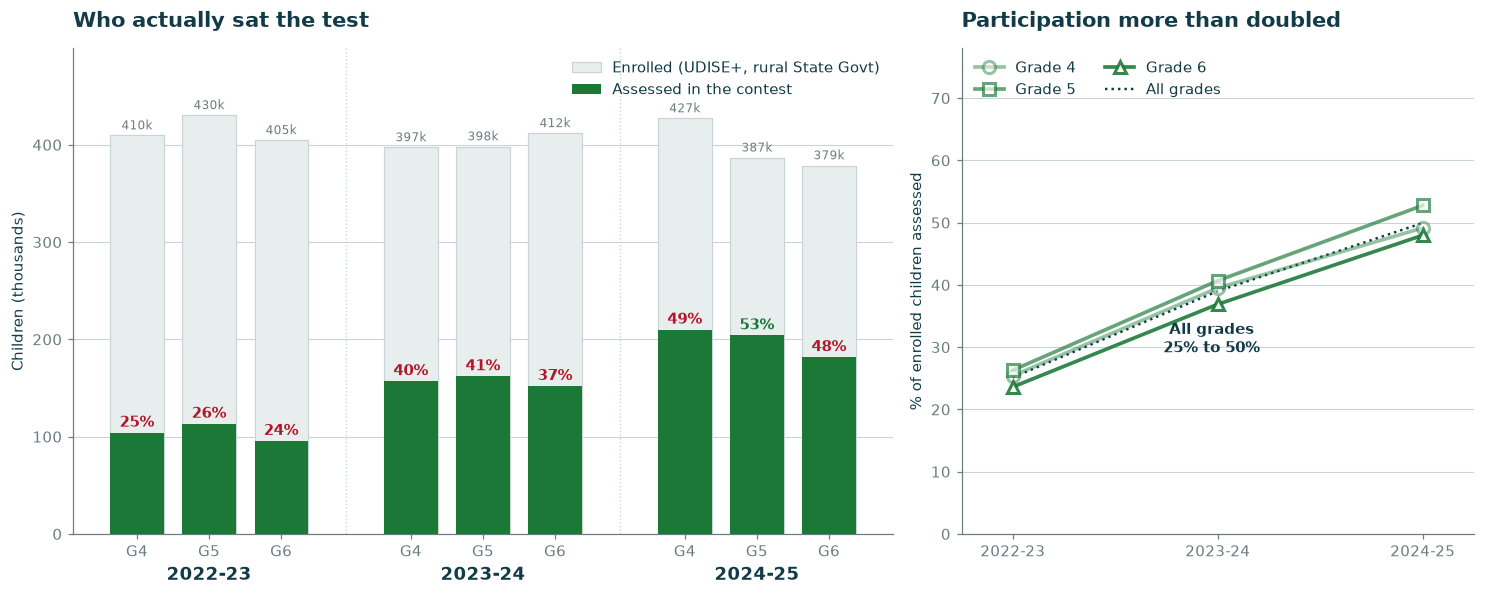

In [7]:
# ---- FIGURE (report figure 11): participation by class and year
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.6, 5.8), gridspec_kw={"width_ratios": [1.6, 1]})
pos, labels, seps, k = [], [], [], 0
for y in YEARS:
    for g in GRADES: pos.append(k); labels.append("G%d" % g); k += 1
    seps.append(k - .5); k += .8
pos = np.array(pos, float); sub = PART.set_index(["year", "Grade"])
enr_v = np.array([sub.loc[(y, g), "enrolled"] for y in YEARS for g in GRADES]) / 1000
ass_v = np.array([sub.loc[(y, g), "assessed"] for y in YEARS for g in GRADES]) / 1000
cov_v = np.array([sub.loc[(y, g), "coverage_pct"] for y in YEARS for g in GRADES])
ax.bar(pos, enr_v, .74, color=PALE, edgecolor=GREY, lw=.8, zorder=2, label="Enrolled (UDISE+, rural State Govt)")
ax.bar(pos, ass_v, .74, color=GREEN, zorder=3, label="Assessed in the contest")
for p, e, a, c in zip(pos, enr_v, ass_v, cov_v):
    ax.annotate("%.0f%%" % c, (p, a), xytext=(0, 4), textcoords="offset points", ha="center",
                fontsize=9.5, fontweight="bold", color=GREEN if c >= 50 else RED)
    ax.annotate("%.0fk" % e, (p, e), xytext=(0, 4), textcoords="offset points", ha="center",
                fontsize=8, color=MUT)
for s in seps[:-1]: ax.axvline(s + .4, color=GREY, lw=.9, ls=":", zorder=1)
ax.set_xticks(pos); ax.set_xticklabels(labels, fontsize=10)
for i, y in enumerate(YEARS):
    ax.annotate(y, (pos[i*3:(i+1)*3].mean(), 0), xytext=(0, -30), textcoords="offset points",
                ha="center", fontsize=11.5, fontweight="bold", color=INK, annotation_clip=False)
ax.set_ylabel("Children (thousands)"); ax.set_ylim(0, enr_v.max() * 1.16)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
ax.set_title("Who actually sat the test", fontsize=13.5, fontweight="bold", loc="left", pad=14)
ax.grid(axis="y", color=GREY, lw=.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for g, mk in zip(GRADES, ("o", "s", "^")):
    bx.plot(range(3), [sub.loc[(y, g), "coverage_pct"] for y in YEARS], "-" + mk, color=GREEN,
            lw=2.4, ms=8, alpha=.45 + .22 * (g - 4), markerfacecolor="white", markeredgewidth=2,
            zorder=3, label="Grade %d" % g)
allv = by_year["coverage_pct"].reindex(YEARS).values
bx.plot(range(3), allv, ":", color=INK, lw=1.6, zorder=2, label="All grades")
bx.annotate("All grades\n%.0f%% to %.0f%%" % (allv[0], allv[-1]), (1, allv[1]), xytext=(-4, -40),
            textcoords="offset points", ha="center", fontsize=10, fontweight="bold", color=INK)
bx.legend(frameon=False, fontsize=9.5, loc="upper left", ncol=2)
bx.set_xticks(range(3)); bx.set_xticklabels(YEARS); bx.set_xlim(-.25, 2.25); bx.set_ylim(0, 78)
bx.set_ylabel("% of enrolled children assessed")
bx.set_title("Participation more than doubled", fontsize=13.5, fontweight="bold", loc="left", pad=14)
bx.grid(axis="y", color=GREY, lw=.7); bx.set_axisbelow(True)
for s in ("top", "right"): bx.spines[s].set_visible(False)
fig.tight_layout(rect=[0, .05, 1, 1])
fig.savefig(os.path.join(FIG, "11_participation.png"), dpi=200, facecolor="white"); plt.show()

In [8]:
# ---- district participation: best 5 and worst 5 (report §1)
import external
alias = external.build_alias_table()
rows = []
for f in udise_enr:
    d = pd.read_csv(f, low_memory=False)
    d = d[(d["management_group"].astype(str).str.strip() == "State Government") &
          (d["rural_urban"].astype(str).str.strip().str.lower() == "rural")]
    tot = sum(pd.to_numeric(d["c%d_%s" % (g, s)], errors="coerce").astype("float64").fillna(0)
              for g in GRADES for s in ("b", "g"))
    t = tot.groupby(d["district"].astype(str).str.strip()).sum().reset_index()
    t.columns = ["district", "enrolled"]; rows.append(t)
U = pd.concat(rows, ignore_index=True)
mu = external.match_districts(U["district"].unique(), alias, "district")
U = (U.merge(mu[["district", "canonical_district"]], on="district", how="left")
       .groupby("canonical_district")["enrolled"].sum().reset_index())

DNAMES = df["District"].astype(str).str.upper().unique()
ma = external.match_districts(DNAMES, alias, "district")
DMAP = dict(zip(ma["district"], ma["canonical_district"]))
df["canonical_district"] = df["District"].astype(str).str.upper().map(DMAP)

A = df.groupby("canonical_district").size().rename("assessed").reset_index()
DP = U.merge(A, on="canonical_district", how="left").fillna({"assessed": 0})
DP["coverage_pct"] = (100 * DP.assessed / DP.enrolled).round(1)
DP = DP.sort_values("coverage_pct", ascending=False).reset_index(drop=True)
DP["rank"] = range(1, len(DP) + 1)
DP.to_csv(os.path.join(TAB, "participation_district.csv"), index=False)
print("TESTED THE MOST\n", DP.head(5)[["rank", "canonical_district", "coverage_pct"]].to_string(index=False))
print("\nTESTED THE LEAST\n", DP.tail(5)[["rank", "canonical_district", "coverage_pct"]].to_string(index=False))
record("top_district_coverage", float(DP.coverage_pct.iloc[0]), 70.1)
record("n_districts_zero", int((DP.coverage_pct == 0).sum()), 2, tol=0)

      district names: 35, matched 100.0%
      district names: 31, matched 100.0%
TESTED THE MOST
  rank canonical_district  coverage_pct
    1        Chitradurga          70.1
    2            Dharwad          66.1
    3    Bengaluru Rural          62.6
    4              Gadag          60.8
    5    Chikkaballapura          59.3

TESTED THE LEAST
  rank canonical_district  coverage_pct
   27              Udupi           5.7
   28   Dakshina Kannada           2.0
   29     Uttara Kannada           0.8
   30    Bengaluru Urban           0.0
   31         Shivamogga           0.0


2

In [9]:
# ---- the finding that breaks the league table
score_by_d = df.groupby("canonical_district")["Score_Pct"].mean()
LT = DP.set_index("canonical_district").join(score_by_d.rename("mean_score")).dropna(subset=["mean_score"])
LT["score_rank"] = LT["mean_score"].rank(ascending=False).astype(int)
r, p = stats.pearsonr(LT.coverage_pct, LT.mean_score)
print("The three HIGHEST-SCORING districts, shown with their participation:\n")
print(LT.nsmallest(3, "score_rank")[["score_rank", "mean_score", "coverage_pct", "rank"]]
        .rename(columns={"rank": "participation_rank"}).round(1).to_string())
print("\ncorrelation(participation, score) = %.2f  (p = %.4f, n = %d districts)" % (r, p, len(LT)))
print("Districts that measure themselves properly look worse. Never publish a rank without coverage.")
record("cov_score_corr", round(r, 2), -0.47)

The three HIGHEST-SCORING districts, shown with their participation:

                    score_rank  mean_score  coverage_pct  participation_rank
canonical_district                                                          
Udupi                        1   74.300003           5.7                  27
Dakshina Kannada             2   72.900002           2.0                  28
Uttara Kannada               3   70.000000           0.8                  29

correlation(participation, score) = -0.47  (p = 0.0095, n = 29 districts)
Districts that measure themselves properly look worse. Never publish a rank without coverage.


np.float64(-0.47)

## 5. Score distribution and descriptive cuts

The wider exploratory picture, before the report's specific arguments.

count    1379087.0
mean          53.1
std           28.7
min            0.0
25%           30.0
50%           55.0
75%           75.0
max          100.0


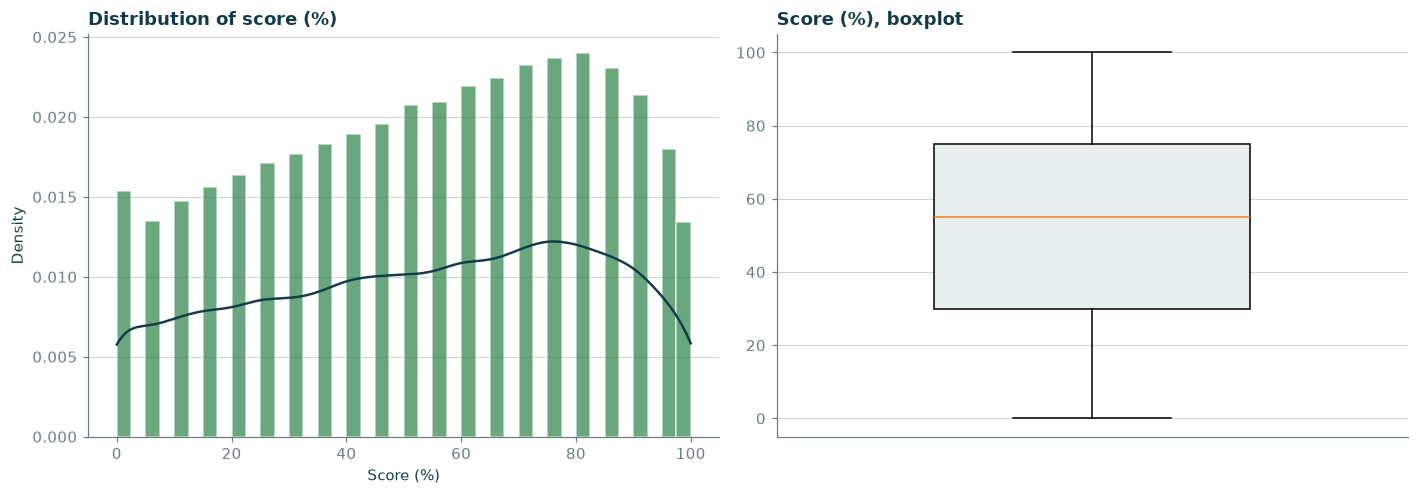

In [10]:
def describe_cut(data, group_cols, value_col="Score_Pct", min_n=1):
    out = (data.groupby(group_cols, observed=True)[value_col]
               .agg(mean="mean", median="median", std="std", n="count").round(2))
    return out[out["n"] >= min_n].sort_values("mean")

print(df["Score_Pct"].describe().round(2).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].hist(df["Score_Pct"].dropna(), bins=40, density=True, alpha=.65,
             color=GREEN, edgecolor="white")
sns.kdeplot(df["Score_Pct"].dropna(), ax=axes[0], color=INK, lw=1.6)
axes[0].set_title("Distribution of score (%)", fontweight="bold", loc="left")
axes[0].set_xlabel("Score (%)"); axes[0].set_ylabel("Density")
sns.boxplot(y=df["Score_Pct"], ax=axes[1], color=PALE)
axes[1].set_title("Score (%), boxplot", fontweight="bold", loc="left")
for a in axes:
    a.grid(axis="y", color=GREY, lw=.7); a.set_axisbelow(True)
    for s in ("top", "right"): a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

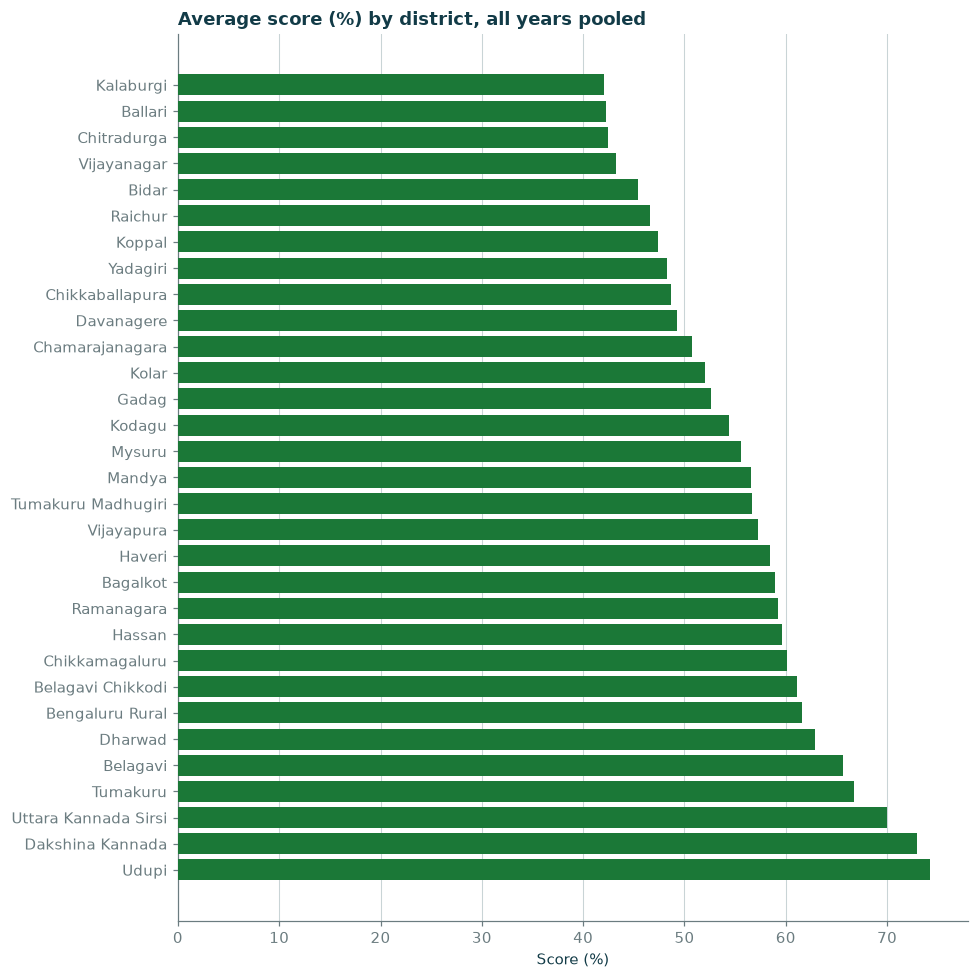

Top 5 districts by score:
                            mean      n
District                              
belagavi              65.660004  56630
tumakuru              66.699997  52084
uttara kannada sirsi  69.959999    801
dakshina kannada      72.919998   1623
udupi                 74.269997   2815

Bottom 5 districts by score:
                   mean      n
District                     
kalaburgi    42.009998  91823
ballari      42.279999  46061
chitradurga  42.410000  87338
vijayanagar  43.259998  61409
bidar        45.400002  42933


In [11]:
by_district = describe_cut(df, "District", min_n=100)
fig, ax = plt.subplots(figsize=(9, 9))
sns.barplot(y=[d.title() for d in by_district.index], x=by_district["mean"], ax=ax, color=GREEN)
ax.set_title("Average score (%) by district, all years pooled", fontweight="bold", loc="left")
ax.set_xlabel("Score (%)"); ax.grid(axis="x", color=GREY, lw=.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("Top 5 districts by score:\n", by_district.tail(5)[["mean", "n"]].to_string())
print("\nBottom 5 districts by score:\n", by_district.head(5)[["mean", "n"]].to_string())

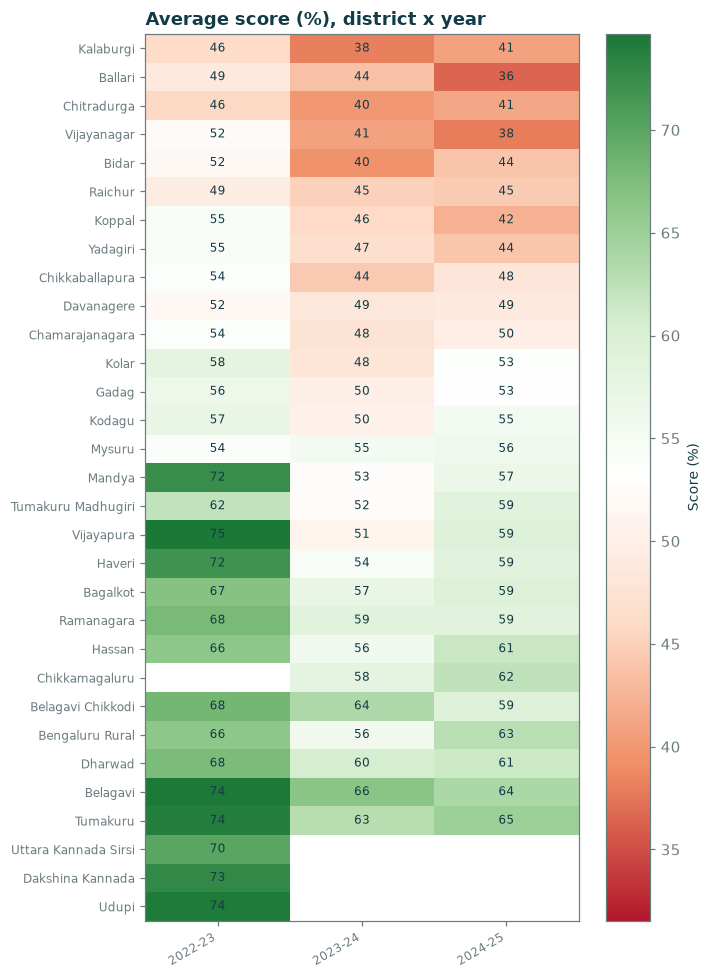

In [12]:
district_year = describe_cut(df, ["District", "Academic_Year"], min_n=30)["mean"].unstack()
district_year = district_year.reindex(by_district.index)
fig, ax = plt.subplots(figsize=(6.5, 9))
sns.heatmap(district_year, annot=True, fmt=".0f", cmap=DIVERGING, center=df.Score_Pct.mean(),
            ax=ax, cbar_kws={"label": "Score (%)"}, linewidths=.6, linecolor="white")
ax.set_yticklabels([t.get_text().title() for t in ax.get_yticklabels()], rotation=0)
ax.set_title("Average score (%), district x year", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

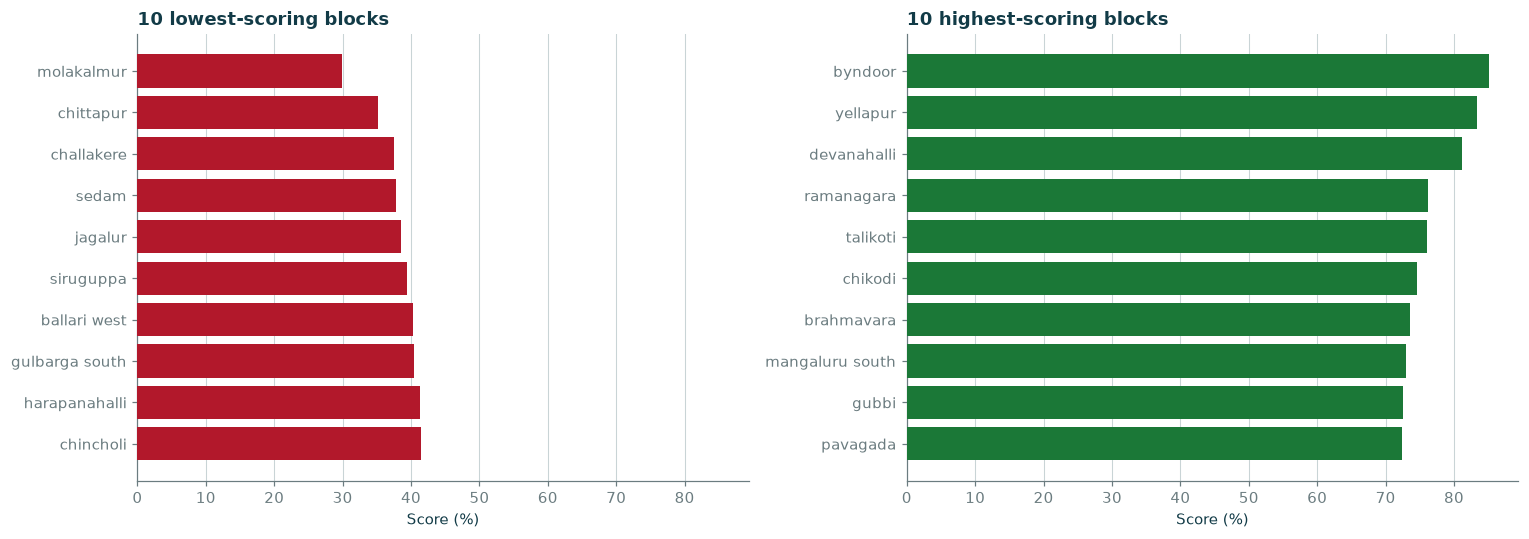

Helper ready: geo_drilldown(district='belagavi', level='Cluster')


In [13]:
by_block = describe_cut(df, ["District", "Block"], min_n=200).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.barplot(data=by_block.nsmallest(10, "mean"), y="Block", x="mean", ax=axes[0], color=RED)
axes[0].set_title("10 lowest-scoring blocks", fontweight="bold", loc="left")
sns.barplot(data=by_block.nlargest(10, "mean"), y="Block", x="mean", ax=axes[1], color=GREEN)
axes[1].set_title("10 highest-scoring blocks", fontweight="bold", loc="left")
for a in axes:
    a.set_xlabel("Score (%)"); a.grid(axis="x", color=GREY, lw=.7); a.set_axisbelow(True)
    for s in ("top", "right"): a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

def geo_drilldown(district=None, block=None, level="GP", min_n=10):
    # descriptive table at Cluster or GP level, filtered to a district and/or block
    sub = df
    if district: sub = sub[sub.District == district.lower()]
    if block:    sub = sub[sub.Block == block.lower()]
    if sub.empty: raise ValueError("no rows for that filter")
    return describe_cut(sub, level, min_n=min_n)
print("Helper ready: geo_drilldown(district='belagavi', level='Cluster')")

## 6. The grade gradient inverted  ·  report §2.1

In [14]:
SGY = (df.groupby(["Grade", "Academic_Year"], observed=True)
         .agg(n=("Score_Pct", "size"), mean_pct=("Score_Pct", "mean"),
              **{c: (c, "mean") for c in COMP_COLS}).reset_index())
SGY["Grade"] = SGY["Grade"].astype(int); SGY["year"] = SGY["Academic_Year"].astype(str)
SGY.drop(columns=["Academic_Year"]).round(2).to_csv(os.path.join(TAB, "state_grade_year.csv"), index=False)
print("MEAN % OF ITEMS CORRECT, by class and year\n")
print(SGY.pivot(index="year", columns="Grade", values="mean_pct").round(1).to_string())

g6 = SGY[SGY.Grade == 6].set_index("year")
for codeq, pub in [("MUL", (51.0, 35.1)), ("DIV", (55.0, 37.6))]:
    a, b = g6.loc[YEARS[0], codeq], g6.loc[YEARS[2], codeq]
    print("\nClass 6 %-15s %.1f%%  ->  %.1f%%   (%+.1f points)"
          % (COMPETENCY_LABELS[codeq], a, b, b - a))
    record("g6_%s_first" % codeq, round(a, 1), pub[0])
    record("g6_%s_last"  % codeq, round(b, 1), pub[1])
for gr, pub in [(4, (49.6, 57.8)), (5, (56.2, 51.7)), (6, (62.5, 49.3))]:
    s = SGY[SGY.Grade == gr].set_index("year")["mean_pct"]
    record("g%d_mean_first" % gr, round(s[YEARS[0]], 1), pub[0])
    record("g%d_mean_last"  % gr, round(s[YEARS[2]], 1), pub[1])

MEAN % OF ITEMS CORRECT, by class and year

Grade            4          5          6
year                                    
2022-23  49.599998  56.099998  62.500000
2023-24  47.799999  51.400002  54.500000
2024-25  57.799999  51.700001  49.299999

Class 6 Multiplication  50.9%  ->  35.1%   (-15.8 points)

Class 6 Division        55.0%  ->  37.6%   (-17.4 points)


In [15]:
# ---- the constant-GP panel: the same places, all three years (report §3, test 1)
MIN_PANEL = 10
def panel_change(grade, codeq, min_n=MIN_PANEL):
    s = (df[df.Grade == grade].groupby(["GP_Code", "Academic_Year"], observed=True)
           .agg(n=(codeq, "count"), v=(codeq, "mean")).reset_index())
    s["year"] = s["Academic_Year"].astype(str)
    s = s[s.n >= min_n]
    keep = s.groupby("GP_Code")["year"].nunique()
    s = s[s.GP_Code.isin(keep[keep == 3].index)]
    w = lambda y: np.average(s[s.year == y].v, weights=s[s.year == y].n)
    return w(YEARS[0]), w(YEARS[2]), s.GP_Code.nunique()

print("CONSTANT-GP PANEL: GPs fielding at least %d children in EVERY year\n" % MIN_PANEL)
for codeq, pf, pl in [("MUL", 50.5, 30.8), ("DIV", 54.5, 32.5)]:
    a, b, k = panel_change(6, codeq)
    raw = g6.loc[YEARS[2], codeq] - g6.loc[YEARS[0], codeq]
    print("Class 6 %-15s panel %.1f -> %.1f (%+.1f pts) vs raw %+.1f pts   [%s GPs]"
          % (COMPETENCY_LABELS[codeq], a, b, b - a, raw, f"{k:,}"))
    record("panel_g6_%s_first" % codeq, round(a, 1), pf)
    record("panel_g6_%s_last"  % codeq, round(b, 1), pl)
    if codeq == "MUL": record("panel_n_gps", k, 2182, tol=40)

a4, b4, k4 = panel_change(4, "DIV")
g4 = SGY[SGY.Grade == 4].set_index("year")
raw4 = g4.loc[YEARS[2], "DIV"] - g4.loc[YEARS[0], "DIV"]
print("\nClass 4 Division      panel %.1f -> %.1f (%+.1f pts) vs raw %+.1f pts   [%s GPs]"
      % (a4, b4, b4 - a4, raw4, f"{k4:,}"))
print("\n  The raw class-4 gain is compositional. It does not survive the same panel that")
print("  confirms the class-6 decline, so we report both.")
record("panel_g4_div_change", round(b4 - a4, 1), -0.6, tol=0.5)
record("raw_g4_div_change",   round(raw4, 1), 5.6, tol=0.5)

CONSTANT-GP PANEL: GPs fielding at least 10 children in EVERY year

Class 6 Multiplication  panel 50.5 -> 30.8 (-19.7 pts) vs raw -15.8 pts   [2,182 GPs]
Class 6 Division        panel 54.5 -> 32.5 (-22.0 pts) vs raw -17.4 pts   [2,182 GPs]

Class 4 Division      panel 39.0 -> 38.4 (-0.6 pts) vs raw +5.6 pts   [2,278 GPs]

  The raw class-4 gain is compositional. It does not survive the same panel that
  confirms the class-6 decline, so we report both.


np.float32(5.6)

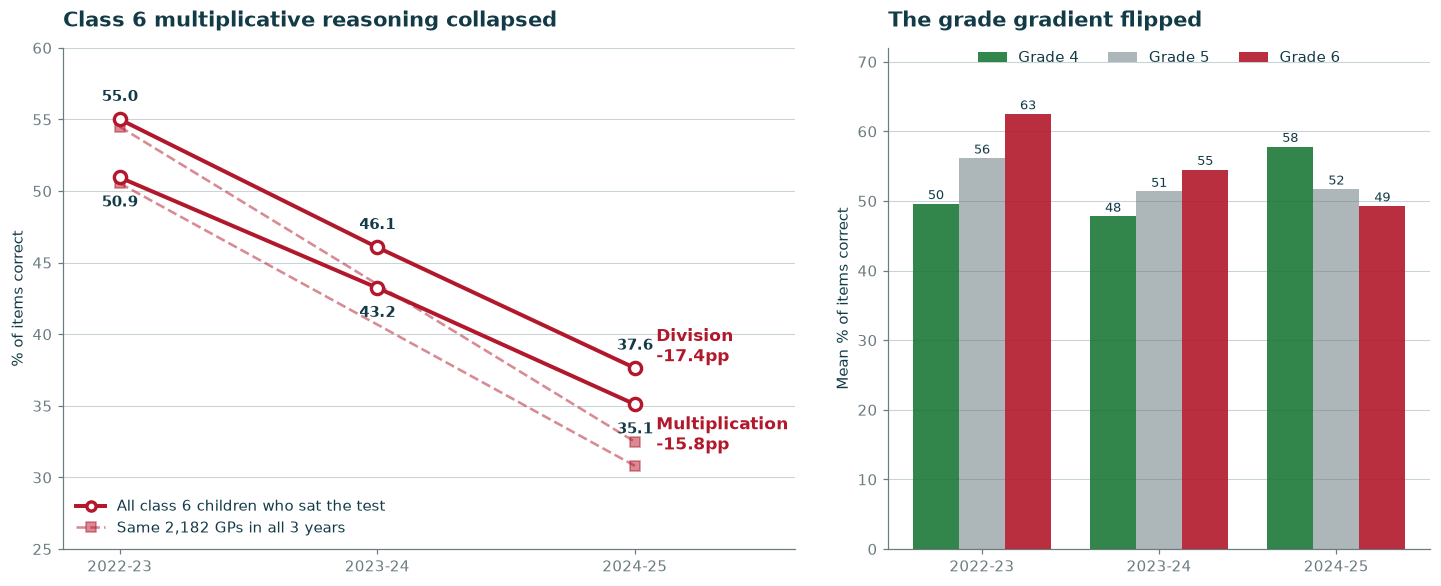

In [16]:
# ---- FIGURE (report figure 10): the collapse, raw and panel
pan = {c: panel_change(6, c) for c in ("MUL", "DIV")}
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.35, 1]})
x = np.arange(3); VOFF = {"DIV": 12, "MUL": -19}
for codeq, lab in (("DIV", "Division"), ("MUL", "Multiplication")):
    v = [g6.loc[y, codeq] for y in YEARS]
    ax.plot(x, v, "-o", color=RED, lw=2.6, ms=8, markerfacecolor="white", markeredgewidth=2.2, zorder=3)
    a, b, _ = pan[codeq]; ax.plot([0, 2], [a, b], "--s", color=RED, lw=1.7, ms=6, alpha=.5, zorder=2)
    for i, y in enumerate(YEARS):
        ax.annotate("%.1f" % v[i], (i, v[i]), xytext=(0, VOFF[codeq]), textcoords="offset points",
                    ha="center", fontsize=10, fontweight="bold", color=INK)
    ax.annotate("%s\n%+.1fpp" % (lab, v[2] - v[0]), (2, v[2]),
                xytext=(14, 14 if codeq == "DIV" else -20), textcoords="offset points",
                ha="left", va="center", fontsize=11, fontweight="bold", color=RED)
ax.plot([], [], "-o", color=RED, lw=2.6, markerfacecolor="white", markeredgewidth=2.2,
        label="All class 6 children who sat the test")
ax.plot([], [], "--s", color=RED, lw=1.7, alpha=.5, label="Same %s GPs in all 3 years" % f"{pan['DIV'][2]:,}")
ax.legend(frameon=False, fontsize=9.5, loc="lower left")
ax.set_xticks(x); ax.set_xticklabels(YEARS); ax.set_xlim(-.22, 2.62); ax.set_ylim(25, 60)
ax.set_ylabel("% of items correct")
ax.set_title("Class 6 multiplicative reasoning collapsed", fontsize=13.5, fontweight="bold", loc="left", pad=14)
ax.grid(axis="y", color=GREY, lw=.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
w = .26
for k, (gd, colr) in enumerate([(4, GREEN), (5, MUT), (6, RED)]):
    v = SGY[SGY.Grade == gd].set_index("year")["mean_pct"].reindex(YEARS).values
    bx.bar(x + (k - 1) * w, v, w, color=colr, alpha=.9 if gd != 5 else .55, label="Grade %d" % gd, zorder=3)
    for i, val in enumerate(v):
        bx.annotate("%.0f" % val, (i + (k - 1) * w, val), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8.5, color=INK)
bx.set_xticks(x); bx.set_xticklabels(YEARS); bx.set_ylim(0, 72); bx.set_ylabel("Mean % of items correct")
bx.legend(frameon=False, fontsize=9.5, ncol=3, loc="upper center", bbox_to_anchor=(.5, 1.02))
bx.set_title("The grade gradient flipped", fontsize=13.5, fontweight="bold", loc="left", pad=14)
bx.grid(axis="y", color=GREY, lw=.7); bx.set_axisbelow(True)
for s in ("top", "right"): bx.spines[s].set_visible(False)
fig.tight_layout(rect=[0, .03, 1, 1])
fig.savefig(os.path.join(FIG, "10_g6_collapse.png"), dpi=200, facecolor="white"); plt.show()

## 7. Boys and girls move together  ·  report §2.2

In [17]:
GEN = (df.dropna(subset=["Gender"]).groupby(["Grade", "Academic_Year", "Gender"], observed=True)
         .agg(n=("Score_Pct", "size"), mean_pct=("Score_Pct", "mean")).reset_index())
GEN["Grade"] = GEN["Grade"].astype(int); GEN["year"] = GEN["Academic_Year"].astype(str)
GEN.drop(columns=["Academic_Year"]).to_csv(os.path.join(TAB, "gender_grade_year.csv"), index=False)
gp_ = GEN.pivot_table(index=["Grade", "year"], columns="Gender", values="mean_pct")
gp_["gap_pp"] = gp_["female"] - gp_["male"]
print("GIRLS MINUS BOYS, by class and year\n"); print(gp_.round(2).to_string())

girls = df.loc[df.Gender == "female", "Score_Pct"].dropna()
boys  = df.loc[df.Gender == "male",   "Score_Pct"].dropna()
pooled = np.sqrt(((len(girls)-1)*girls.var(ddof=1) + (len(boys)-1)*boys.var(ddof=1)) /
                 (len(girls)+len(boys)-2))
d_g = (girls.mean() - boys.mean()) / pooled
print("\nOverall  girls %.1f%%   boys %.1f%%   gap %+.1f points   Cohen's d = %.3f"
      % (girls.mean(), boys.mean(), girls.mean() - boys.mean(), d_g))
print("mean absolute gap across the 9 class-years %.2f | largest %.2f"
      % (gp_.gap_pp.abs().mean(), gp_.gap_pp.abs().max()))
print("\nA Cohen's d of 0.07 means a randomly chosen girl beats a randomly chosen boy about")
print("52 times in 100 instead of 50. Real, but not where an intervention should start.")
record("girls_mean", round(girls.mean(), 1), 54.0)
record("boys_mean",  round(boys.mean(), 1), 52.0)
record("cohens_d",   round(d_g, 3), 0.071, tol=0.012)
record("gender_gap_mean_abs", round(gp_.gap_pp.abs().mean(), 2), 2.12, tol=0.12)
record("gender_gap_max_abs",  round(gp_.gap_pp.abs().max(), 2), 3.02, tol=0.12)

GIRLS MINUS BOYS, by class and year

Gender            female       male  gap_pp
Grade year                                 
4     2022-23  50.570000  48.490002    2.08
      2023-24  48.570000  46.889999    1.68
      2024-25  59.040001  56.450001    2.59
5     2022-23  57.340000  54.779999    2.56
      2023-24  52.130001  50.459999    1.67
      2024-25  52.400002  50.889999    1.51
6     2022-23  63.290001  61.689999    1.60
      2023-24  55.919998  52.900002    3.02
      2024-25  50.380001  48.029999    2.36

Overall  girls 54.0%   boys 52.0%   gap +2.0 points   Cohen's d = 0.071
mean absolute gap across the 9 class-years 2.12 | largest 3.02

A Cohen's d of 0.07 means a randomly chosen girl beats a randomly chosen boy about
52 times in 100 instead of 50. Real, but not where an intervention should start.


np.float32(3.02)

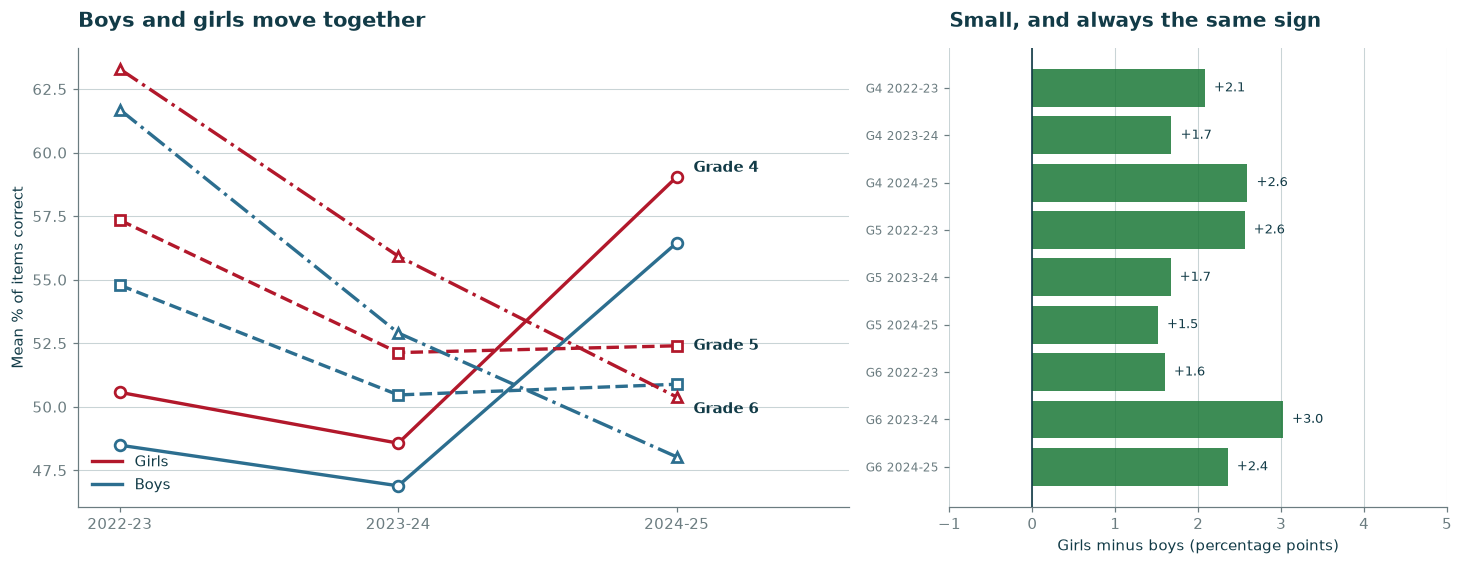

In [18]:
# ---- FIGURE (report figure 12)
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.4, 5.4), gridspec_kw={"width_ratios": [1.55, 1]})
STY = {4: ("o", "-"), 5: ("s", "--"), 6: ("^", "-.")}
for g in GRADES:
    mk, ls = STY[g]
    ax.plot(range(3), [gp_.loc[(g, y), "female"] for y in YEARS], ls + mk, color=RED, lw=2.2, ms=7,
            markerfacecolor="white", markeredgewidth=1.8, zorder=3)
    ax.plot(range(3), [gp_.loc[(g, y), "male"] for y in YEARS], ls + mk, color=BLUE, lw=2.2, ms=7,
            markerfacecolor="white", markeredgewidth=1.8, zorder=3)
    ax.annotate("Grade %d" % g, (2, gp_.loc[(g, YEARS[2]), "female"]),
                xytext=(11, {4: 6, 5: 0, 6: -8}[g]), textcoords="offset points",
                fontsize=10, fontweight="bold", color=INK, va="center")
ax.plot([], [], "-", color=RED, lw=2.2, label="Girls"); ax.plot([], [], "-", color=BLUE, lw=2.2, label="Boys")
ax.legend(frameon=False, fontsize=10, loc="lower left")
ax.set_xticks(range(3)); ax.set_xticklabels(YEARS); ax.set_xlim(-.15, 2.62)
ax.set_ylabel("Mean % of items correct")
ax.set_title("Boys and girls move together", fontsize=13.5, fontweight="bold", loc="left", pad=14)
ax.grid(axis="y", color=GREY, lw=.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
gg = gp_.reset_index()
bx.barh(range(len(gg)), gg.gap_pp, color=[GREEN if v > 0 else RED for v in gg.gap_pp], alpha=.85, zorder=3)
bx.axvline(0, color=INK, lw=1.1, zorder=4)
bx.set_yticks(range(len(gg))); bx.set_yticklabels(["G%d %s" % (r.Grade, r.year) for _, r in gg.iterrows()],
                                                  fontsize=8); bx.invert_yaxis()
for i, v in enumerate(gg.gap_pp):
    bx.annotate("%+.1f" % v, (v, i), xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=8.5, color=INK)
bx.set_xlim(-1, 5); bx.set_xlabel("Girls minus boys (percentage points)")
bx.set_title("Small, and always the same sign", fontsize=13, fontweight="bold", loc="left", pad=14)
bx.grid(axis="x", color=GREY, lw=.7); bx.set_axisbelow(True)
for s in ("top", "right", "left"): bx.spines[s].set_visible(False)
fig.tight_layout(rect=[0, .03, 1, 1])
fig.savefig(os.path.join(FIG, "12_gender_grade_year.png"), dpi=200, facecolor="white"); plt.show()

Gender          female   male  gap_girls_minus_boys
Measurement      51.46  51.46                 -0.00
Mensuration      56.33  54.70                  1.62
Shapes           54.62  52.57                  2.04
Subtraction      50.28  48.23                  2.05
Number Sense     60.54  58.47                  2.07
Division         44.37  42.00                  2.37
Place Value      55.63  53.15                  2.48
Addition         62.24  59.56                  2.69
Fractions        64.77  61.90                  2.86
Data Handling    60.68  57.76                  2.92
Multiplication   50.34  47.00                  3.35


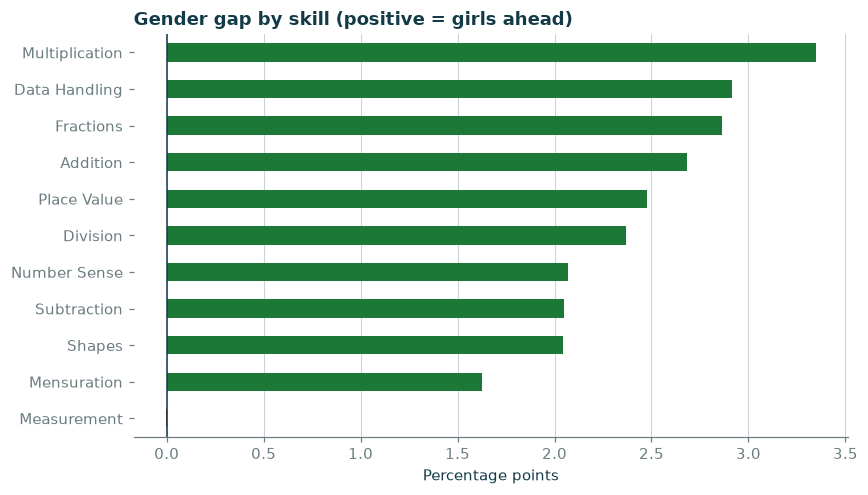

In [19]:
# ---- gender gap by skill
comp_gender = df.groupby("Gender", observed=True)[COMP_COLS].mean().T
comp_gender["gap_girls_minus_boys"] = comp_gender["female"] - comp_gender["male"]
comp_gender.index = [COMPETENCY_LABELS[c] for c in comp_gender.index]
print(comp_gender.round(2).sort_values("gap_girls_minus_boys").to_string())
fig, ax = plt.subplots(figsize=(8, 4.6))
s = comp_gender["gap_girls_minus_boys"].sort_values()
s.plot(kind="barh", ax=ax, color=[GREEN if v > 0 else RED for v in s])
ax.axvline(0, color=INK, lw=1)
ax.set_title("Gender gap by skill (positive = girls ahead)", fontweight="bold", loc="left")
ax.set_xlabel("Percentage points"); ax.grid(axis="x", color=GREY, lw=.7); ax.set_axisbelow(True)
for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 8. All 11 competencies, all classes, all years  ·  report §2.3

In [20]:
COMPY = (df.melt(id_vars=["Grade", "Academic_Year"], value_vars=COMP_COLS,
                 var_name="code", value_name="v").dropna(subset=["v"])
           .groupby(["code", "Grade", "Academic_Year"], observed=True)["v"].mean().reset_index())
COMPY["Grade"] = COMPY["Grade"].astype(int); COMPY["year"] = COMPY["Academic_Year"].astype(str)
COMPY["competency"] = COMPY["code"].map(COMPETENCY_LABELS)
COMPY[["competency", "Grade", "year", "v"]].rename(columns={"v": "pct_correct"}) \
     .to_csv(os.path.join(TAB, "competency_grade_year.csv"), index=False)

pooled_comp = df[COMP_COLS].mean().sort_values()
pooled_comp.index = [COMPETENCY_LABELS[c] for c in pooled_comp.index]
print("POOLED ACROSS ALL CLASSES AND YEARS, % of items correct\n")
print(pooled_comp.round(1).to_string())
for name, codeq, pub in [("Division", "DIV", 43.3), ("Multiplication", "MUL", 48.8),
                         ("Addition", "ADD", 61.0), ("Number Sense", "NS", 59.6)]:
    record("pooled_" + codeq, round(df[codeq].mean(), 1), pub, tol=0.7)

POOLED ACROSS ALL CLASSES AND YEARS, % of items correct

Division          43.3
Multiplication    48.8
Subtraction       49.3
Measurement       51.5
Shapes            53.7
Place Value       54.5
Mensuration       55.6
Data Handling     59.3
Number Sense      59.6
Addition          61.0
Fractions         63.4


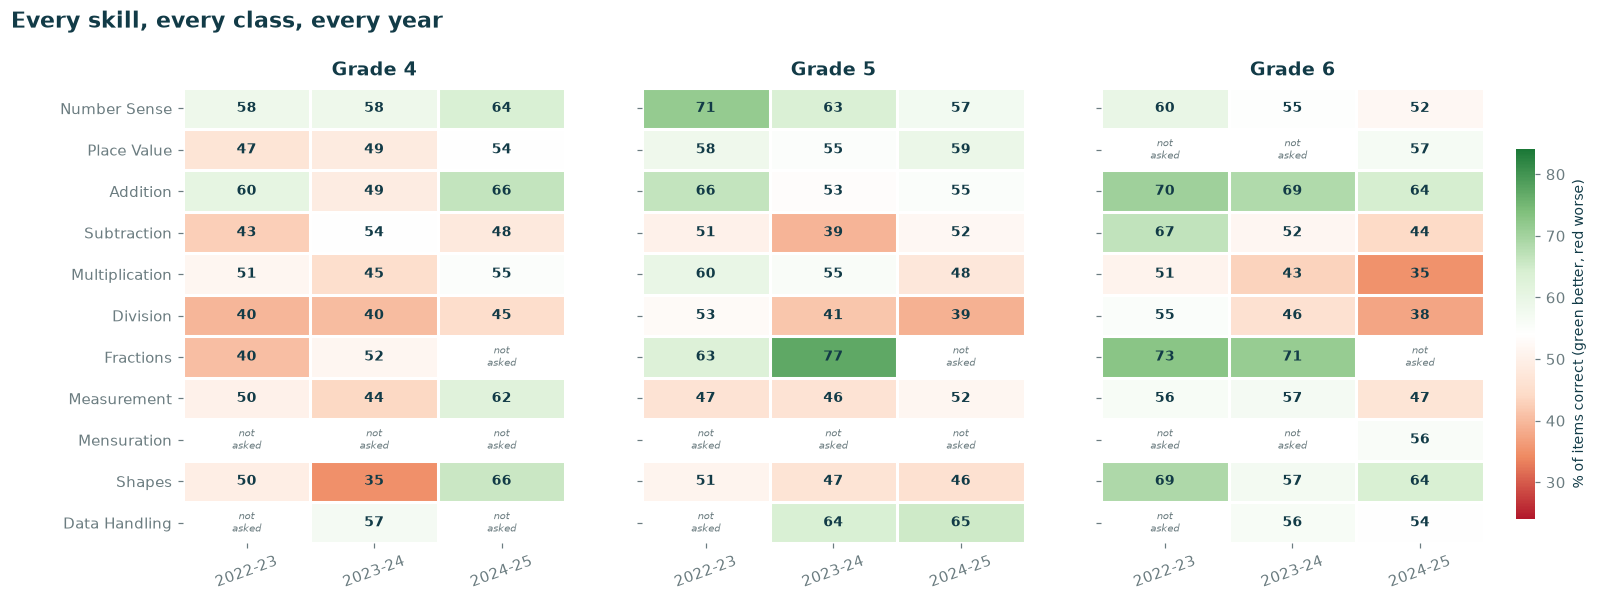

In [21]:
# ---- FIGURE (report figure 13): every skill, class by class, year by year
ORDER = ["NS", "PV", "ADD", "SUB", "MUL", "DIV", "FRAC", "MEA", "MENSU", "SHAPE", "DH"]
fig, axes = plt.subplots(1, 3, figsize=(14.6, 5.6), sharey=True)
vcen = COMPY.v.mean()
for k, g in enumerate(GRADES):
    axg = axes[k]
    M = np.full((len(ORDER), 3), np.nan)
    for i, c in enumerate(ORDER):
        for j, y in enumerate(YEARS):
            s = COMPY[(COMPY.code == c) & (COMPY.Grade == g) & (COMPY.year == y)]
            if len(s): M[i, j] = s.v.iloc[0]
    im = axg.imshow(M, cmap=DIVERGING, vmin=vcen - 30, vmax=vcen + 30, aspect="auto")
    for i in range(len(ORDER)):
        for j in range(3):
            if np.isfinite(M[i, j]):
                axg.text(j, i, "%.0f" % M[i, j], ha="center", va="center", fontsize=9,
                         fontweight="bold", color=INK)
            else:
                axg.text(j, i, "not\nasked", ha="center", va="center", fontsize=6.5,
                         color=MUT, style="italic")
    axg.set_xticks(range(3)); axg.set_xticklabels(YEARS, fontsize=9.5, rotation=20)
    axg.set_title("Grade %d" % g, fontsize=12.5, fontweight="bold", color=INK, pad=8)
    axg.set_xticks(np.arange(-.5, 3, 1), minor=True)
    axg.set_yticks(np.arange(-.5, len(ORDER), 1), minor=True)
    axg.grid(which="minor", color="white", lw=2); axg.tick_params(which="minor", length=0)
    for s in axg.spines.values(): s.set_visible(False)
axes[0].set_yticks(range(len(ORDER)))
axes[0].set_yticklabels([COMPETENCY_LABELS[c] for c in ORDER], fontsize=10)
cax = fig.add_axes([.945, .16, .012, .60]); cb = fig.colorbar(im, cax=cax)
cb.set_label("% of items correct (green better, red worse)", fontsize=9); cb.outline.set_visible(False)
fig.suptitle("Every skill, every class, every year", fontsize=14.5, fontweight="bold",
             color=INK, x=.008, ha="left", y=.985)
fig.subplots_adjust(top=.86, bottom=.12, left=.115, right=.925)
fig.savefig(os.path.join(FIG, "13_competency_spectrum.png"), dpi=200, facecolor="white"); plt.show()

In [22]:
# ---- the prerequisite ladder: skills stack (report §2.3)
def lift(prereq, dependent, thresh=50.0):
    s = df[[prereq, dependent]].dropna()
    has = s[prereq] >= thresh
    a = 100 * (s.loc[has, dependent] >= thresh).mean()
    b = 100 * (s.loc[~has, dependent] >= thresh).mean()
    return a, b, a - b
print("Share clearing a skill, split by whether the earlier skill was cleared\n")
for pr, dep, pub in [("ADD", "SUB", 48), ("MUL", "DIV", 45)]:
    a, b, l = lift(pr, dep)
    print("  %-14s -> %-14s   %.0f%% vs %.0f%%   lift %+.0f points"
          % (COMPETENCY_LABELS[pr], COMPETENCY_LABELS[dep], a, b, l))
    record("lift_%s_%s" % (pr, dep), round(l), pub, tol=7)
print("\nYou cannot fix division by drilling division. Fix what comes before it.")

Share clearing a skill, split by whether the earlier skill was cleared

  Addition       -> Subtraction      72% vs 24%   lift +48 points
  Multiplication -> Division         72% vs 27%   lift +45 points

You cannot fix division by drilling division. Fix what comes before it.


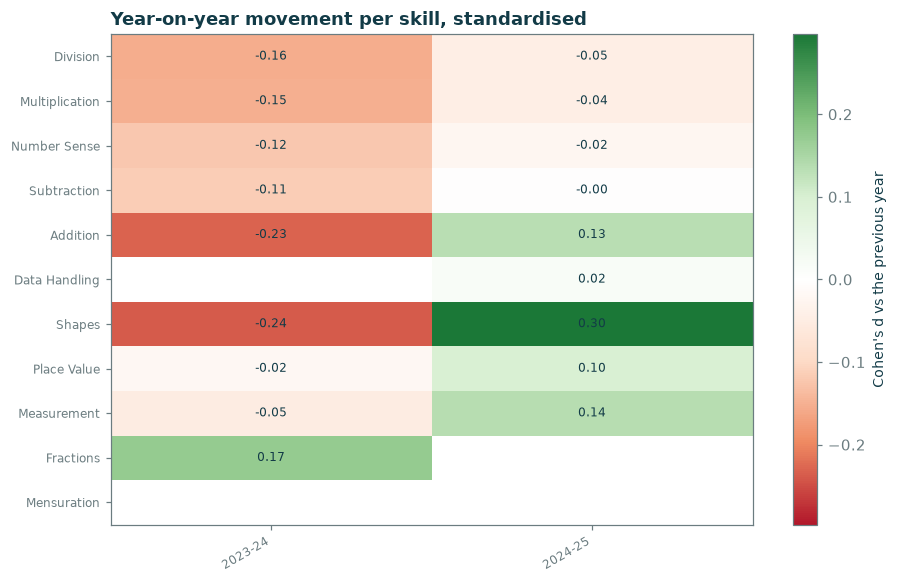

Negative means the skill got worse. |d| under 0.2 is negligible, 0.2-0.5 small, 0.5-0.8 medium.


In [23]:
# ---- year-on-year effect size per skill (Cohen's d), a scale-free view of the movement
def cohens_d(x1, x2):
    x1, x2 = x1.dropna(), x2.dropna()
    if len(x1) < 2 or len(x2) < 2: return np.nan
    sp = np.sqrt(((len(x1)-1)*x1.var(ddof=1) + (len(x2)-1)*x2.var(ddof=1)) / (len(x1)+len(x2)-2))
    return np.nan if sp == 0 else (x2.mean() - x1.mean()) / sp

rows = []
for codeq in COMP_COLS:
    for y1, y2 in zip(YEARS[:-1], YEARS[1:]):
        rows.append({"Skill": COMPETENCY_LABELS[codeq], "Year_To": y2,
                     "Cohens_d": cohens_d(df.loc[df.Academic_Year == y1, codeq],
                                          df.loc[df.Academic_Year == y2, codeq])})
EFF = pd.DataFrame(rows)
piv = EFF.pivot(index="Skill", columns="Year_To", values="Cohens_d")
piv = piv.loc[piv.mean(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(8.5, 5.4))
sns.heatmap(piv, annot=True, fmt=".2f", cmap=DIVERGING, center=0, ax=ax,
            cbar_kws={"label": "Cohen's d vs the previous year"}, linewidths=.6, linecolor="white")
ax.set_title("Year-on-year movement per skill, standardised", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()
print("Negative means the skill got worse. |d| under 0.2 is negligible, 0.2-0.5 small, 0.5-0.8 medium.")

## 9. The hypothesis engine, 36 tests  ·  report §3

The heavy machinery lives in `src/` so it stays importable and testable. These cells run it end
to end, then print the two tables the report publishes. `run_all.py` also writes `manifest.yml`,
`claims.json`, the Track-2 predictions and the interactive dashboard.

In [24]:
# PRE-FLIGHT. Excel takes an exclusive lock on any CSV or XLSX it has open, and every
# script below then dies with a bare PermissionError from deep inside pandas. Catch it once,
# here, and say exactly which file to close.
def locked_outputs():
    bad = []
    for root, _, files in os.walk("outputs"):
        for fn in files:
            if not fn.lower().endswith((".csv", ".xlsx", ".html", ".png")): continue
            fp = os.path.join(root, fn)
            try:
                with open(fp, "a"): pass
            except PermissionError:
                bad.append(fp)
    return bad

_locked = locked_outputs()
if _locked:
    raise SystemExit(
        "STOP. These output files are open in another program, almost certainly Excel:\n"
        + "\n".join("   " + f for f in _locked)
        + "\n\nQuit Excel completely, then re-run this cell. Nothing has been changed.")
print("pre-flight: no locked files in outputs/, safe to write")

def run(script, minutes=15):
    print("\n" + "=" * 74); print("RUNNING  python " + script); print("=" * 74)
    p = subprocess.run([sys.executable, script], capture_output=True, text=True, timeout=minutes * 60)
    print("\n".join((p.stdout or "").strip().split("\n")[-18:]))
    if p.returncode != 0:
        err = (p.stderr or "")
        if "PermissionError" in err:
            import re as _re
            f = _re.findall(r"PermissionError.*?'([^']+)'", err)
            raise SystemExit("%s could not write %s.\nThat file is open in Excel. Close it and re-run."
                             % (script, f[0] if f else "an output file"))
        print("\nSTDERR:\n", err[-2500:]); raise RuntimeError(script + " failed")

run("src/run_all.py")             # QA, analyses, external joins, model, figures, dashboard
run("src/fix_coverage.py")        # corrected coverage denominator, asserted against UDISE
run("src/day1_verdicts.py")       # hypotheses H1-H13
run("src/extra_hypotheses.py")    # hypotheses EH1-EH24
run("src/build_hypothesis_xlsx.py")

# run_all.py wipes outputs/ before it starts, which deletes figures 10 to 13 that sections
# 4 to 8 above just drew. Rebuild them from their standalone scripts so the folder on disk
# matches what this notebook displayed.
run("src/figure_participation.py")      # 11_participation.png
run("src/figure_g6_collapse.py")        # 10_g6_collapse.png
run("src/figure_report_extras.py")      # 12_gender_grade_year.png, 13_competency_spectrum.png

# same trap, one table. Section 3 wrote state_grade_year.csv before the wipe, so the
# file two report sections cite was being deleted right here. SGY is still in memory.
SGY.drop(columns=["Academic_Year"]).round(2).to_csv(
    os.path.join(TAB, "state_grade_year.csv"), index=False)
print("restored outputs/tables/state_grade_year.csv")

print("\npipeline complete")

pre-flight: no locked files in outputs/, safe to write

RUNNING  python src/run_all.py

[ 83.3s] DASHBOARD

[ 83.4s] build dashboard
      dashboard: dashboard.html (5.0 MB)
          done in 3.5s

[ 86.9s] MANIFEST AND CLAIMS
          -> manifest.yml (60 output files)
          -> claims.json (18 claims, template schema)

FINISHED in 87.0 seconds
All steps completed with no failures.
Outputs in: outputs/    Read outputs/tables/qa_flags.csv FIRST.

Full log written to outputs/RUN_LOG.txt

RUNNING  python src/fix_coverage.py
   district  <- District                     
   block     <- Block                        
   cluster   <- Cluster                      
   gp        <- GP                           
   gender    <- Gender                       
   score     <- NOT FOUND                      <-- check config.MANUAL_OVERRIDES
   items     <- 20 columns via name pattern + binary check
               Q1, Q2, Q3, Q4, Q5, Q6 ... Q20
   ------------------------

   in-memory size: 526 M

In [25]:
MENU = pd.read_csv("outputs/tables/hypothesis_menu.csv")
print("36 hypotheses tested. Verdicts:", MENU.verdict.value_counts().to_dict())
record("n_hypotheses", len(MENU), 36, tol=0)
record("n_supported", int((MENU.verdict == "SUPPORTED").sum()), 19, tol=0)
record("n_discarded", int((MENU.verdict == "DISCARD").sum()), 14, tol=0)

print("\n" + "=" * 74)
print("THE CRITICAL TEST: does the decline survive the participation story?")
print("=" * 74 + "\n")
for h in ["EH1", "EH3", "EH5", "EH6", "EH4", "EH22", "EH2"]:
    r = MENU[MENU.id == h].iloc[0]
    print("%-5s %-9s %s" % (r.id, r.verdict, r.hypothesis))
    print("        %s\n" % str(r.effect)[:155])
print("Six designs, different weaknesses, all landing between 18 and 22 points.")
print("Two point the OPPOSITE way: expansion flattered the raw trend rather than causing the fall.")

36 hypotheses tested. Verdicts: {'SUPPORTED': 19, 'DISCARD': 14, 'WEAK': 3}

THE CRITICAL TEST: does the decline survive the participation story?

EH1   SUPPORTED G6 multiplicative decline survives inside a constant-GP panel (same GPs all 3 years)
        panel (k=2182 GPs): mult 50.5->30.8 (-19.7pp vs raw -15.8pp, 125% persists); div 54.5->32.5 (-22.0pp vs raw -17.4pp, 127% persists)

EH3   SUPPORTED G6 decline present even in districts whose coverage changed least
        bottom-tercile |d_cov| (9 districts, mean |d_cov|=4.2pp): mult -18.7pp, div -21.5pp (all-district: -20.1/-22.6)

EH5   SUPPORTED A G6 multiplication decline remains after controlling district coverage change
        regression d(mult) = -19.32 -0.03*d_cov (n=25); predicted decline at zero coverage change: -19.3pp (raw mean -20.1pp, sd 4.1)

EH6   SUPPORTED G6 decline appears even in districts already deeply covered in 2022-23 (>=40%)
        11 districts with 2022-23 coverage >=40%: mult -19.8pp, div -21.7pp

EH4   

In [26]:
print("THE OTHER DECISIVE TESTS\n")
for h in ["EH11", "H12", "EH9", "EH8", "H5", "EH19", "EH7", "EH14", "EH20", "H4", "H1", "H2", "EH17"]:
    s = MENU[MENU.id == h]
    if not len(s): continue
    r = s.iloc[0]
    print("%-5s %-9s %s" % (r.id, r.verdict, r.hypothesis))
    print("        %s\n" % str(r.effect)[:155])
print("Full register with method, assumptions and break-conditions: outputs/HYPOTHESIS_REGISTER.xlsx")

THE OTHER DECISIVE TESTS

EH11  SUPPORTED Contest district ranking agrees with ASER 2024 rural arithmetic (like-for-like: rural, same age band)
        Spearman rho=0.56 (p=0.00362) vs ASER Std6-8 division; rho=0.30 (p=0.141) vs the other scale (n=25 districts)

H12   WEAK      Akshara district ranking replicates in PARAKH RS 2024 grade-6 maths (govt schools)
        Spearman rho=0.51 (p=0.00431, n=29 districts)

EH9   SUPPORTED Girls still lead in districts where boys and girls are assessed at near-equal rates (|coverage gap|<=2pp)
        balanced district-years (n=25): girls-boys score gap +3.57pp (all: +2.79pp)

EH8   DISCARD   Differential participation by gender inflates the measured girls' lead
        r=-0.47 (p=1.25e-05, n=80 district-years) between (girls-boys coverage) and (girls-boys score); the sign is negative: where girls are over-assessed the mea

H5    SUPPORTED Kalyana Karnataka (371J) gap, and whether inputs explain it
        raw gap -13.3 pp; after controlling ptr_

## 10. Where the variation lives  ·  report §4.1

Two views. The student-level split is what the report publishes. The GP-level rerun answers a
fair objection: the "within GP" share is not a GP effect, it bundles school, teacher, household
and child, and those cannot be separated because the data carries no school or student ID.

STUDENT-LEVEL NESTED DECOMPOSITION

                              level  pct_of_total
                           District      7.600000
            Block (within district)      3.000000
             Cluster (within block)      7.100000
                GP (within cluster)      4.500000
Within GP: school, household, child     78.400002


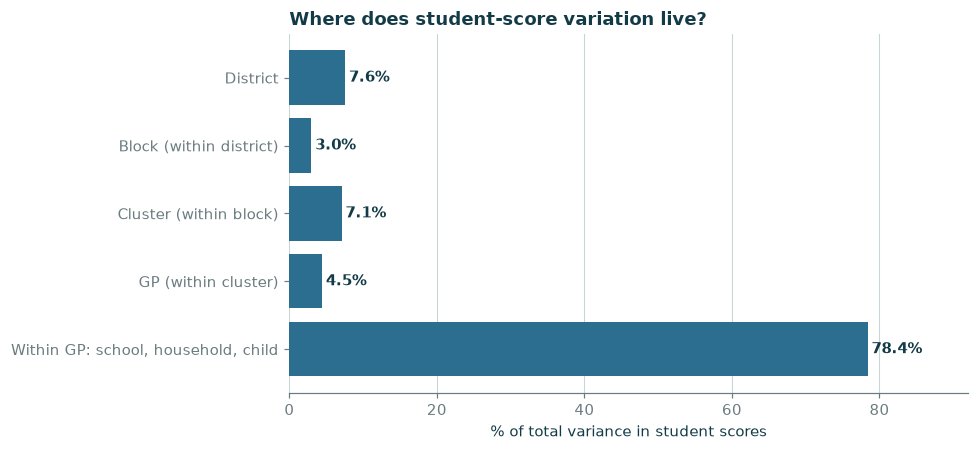

In [27]:
V = df[["Score_Pct", "District", "Block", "Cluster", "GP_Code"]].dropna(subset=["Score_Pct"]).copy()
gm = V.Score_Pct.mean(); sst = float(((V.Score_Pct - gm) ** 2).sum())
V["d_m"] = V.groupby("District", observed=True)["Score_Pct"].transform("mean")
V["b_m"] = V.groupby(["District", "Block"], observed=True)["Score_Pct"].transform("mean")
V["c_m"] = V.groupby(["District", "Block", "Cluster"], observed=True)["Score_Pct"].transform("mean")
V["g_m"] = V.groupby("GP_Code")["Score_Pct"].transform("mean")
parts = {"District": ((V.d_m - gm) ** 2).sum(),
         "Block (within district)": ((V.b_m - V.d_m) ** 2).sum(),
         "Cluster (within block)": ((V.c_m - V.b_m) ** 2).sum(),
         "GP (within cluster)": ((V.g_m - V.c_m) ** 2).sum(),
         "Within GP: school, household, child": ((V.Score_Pct - V.g_m) ** 2).sum()}
NEST = pd.DataFrame({"level": list(parts), "pct_of_total": [100 * v / sst for v in parts.values()]})
print("STUDENT-LEVEL NESTED DECOMPOSITION\n"); print(NEST.round(1).to_string(index=False))
record("within_gp_pct", round(NEST.pct_of_total.iloc[-1]), 78, tol=4)
record("district_pct",  round(NEST.pct_of_total.iloc[0], 1), 6.7, tol=1.2)

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.barplot(data=NEST, y="level", x="pct_of_total", ax=ax, color=BLUE)
for i, v in enumerate(NEST.pct_of_total):
    ax.text(v + .5, i, "%.1f%%" % v, va="center", fontsize=10, fontweight="bold", color=INK)
ax.set_xlabel("% of total variance in student scores"); ax.set_ylabel("")
ax.set_title("Where does student-score variation live?", fontweight="bold", loc="left")
ax.grid(axis="x", color=GREY, lw=.7); ax.set_axisbelow(True); ax.set_xlim(0, 92)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
del V


RUNNING  python src/variance_gp_level.py
   Remainder: the GP itself         5018       100.0%        21.5%

TESTING THE STATED INFERENCE: 'variation comes more from districts and clusters
than from blocks and GPs'
  raw, each level alone:      district 31.1%  block 45.8%  cluster 73.8%
  df-adjusted, each alone:    district 30.7%  block 44.0%  cluster 45.9%
  new information each adds:  block adds 14.7%, cluster adds 32.7%, GP itself 21.5%

  district beats block?          NO
  cluster beats block (raw)?     YES
  cluster beats block (adjusted)? YES
  GP itself is the largest share? NO

wrote outputs/figures/16_variance_gp_level.png
wrote outputs/tables/variance_gp_level.csv, variance_gp_level_sequential.csv

EACH LEVEL ALONE, on the differences BETWEEN GP averages

                  level  n_groups  raw_pct_of_between_place_variance  df_adjusted_pct
               District        29                               31.1             30.7
                  Block       166                

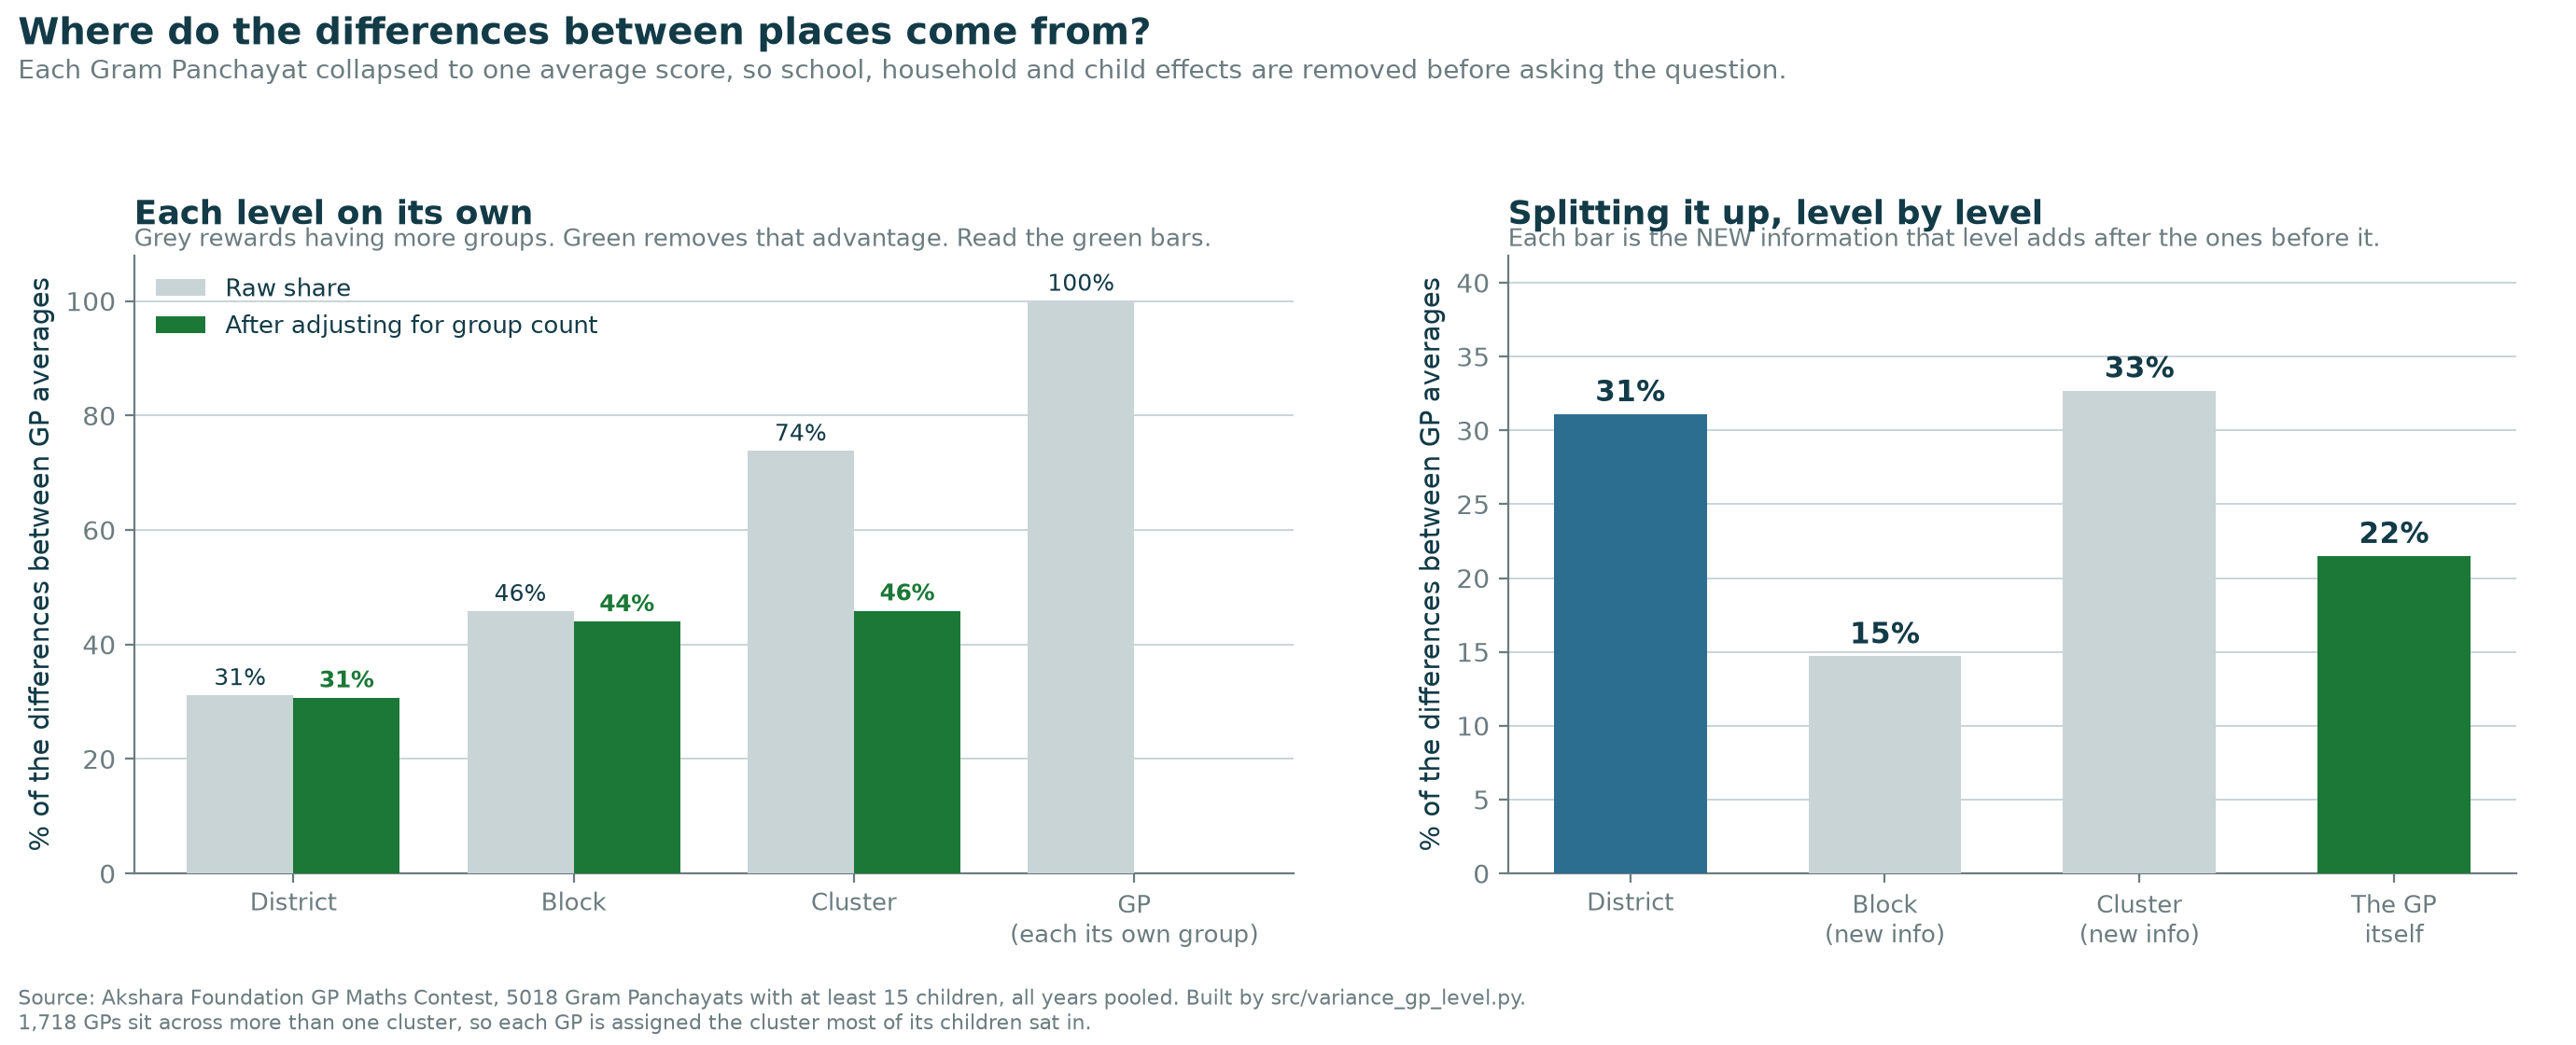

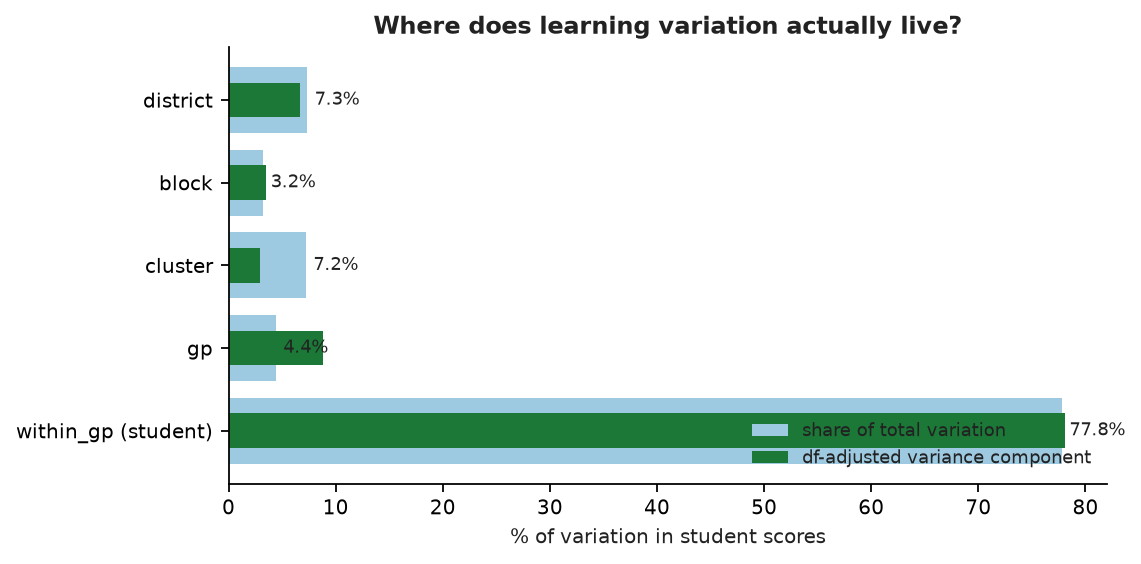

In [28]:
# ---- GP-level rerun: collapse every GP to one mean FIRST, then decompose (report figure 16)
run("src/variance_gp_level.py")
R = pd.read_csv("outputs/tables/variance_gp_level.csv")
Q = pd.read_csv("outputs/tables/variance_gp_level_sequential.csv")
print("\nEACH LEVEL ALONE, on the differences BETWEEN GP averages\n"); print(R.to_string(index=False))
print("\nBUILT UP LEVEL BY LEVEL\n"); print(Q.to_string(index=False))
print("\nRaw shares reward whichever level has the most groups (2,584 clusters against 166 blocks),")
print("so read the df-adjusted column. Cluster adds the most new information, then district,")
print("then the GP itself, with block last.")
display(Image(filename=os.path.join(FIG, "16_variance_gp_level.png")))
display(Image(filename=os.path.join(FIG, "01_variance_signature.png")))

## 11. Kalyana Karnataka against the rest  ·  report §4.2

In [29]:
xw = pd.read_csv("external_data/karnataka_district_crosswalk.csv")
kk_names = set()
for _, r in xw[xw.is_371J_kalyana_karnataka == 1].iterrows():
    for col in ("current_name", "census2011_name", "nfhs5_name", "aser2024_name"):
        v = str(r.get(col, "")).strip().upper()
        if v and v != "NAN": kk_names.add(v)
    for a in str(r.get("alt_spellings", "")).split(";"):
        if a.strip(): kk_names.add(a.strip().upper())
df["Region"] = np.where(df["canonical_district"].astype(str).str.upper().isin(kk_names),
                        "Kalyana Karnataka", "Rest of Karnataka")
print(df.Region.value_counts().to_string())
print("\nKK districts found:", sorted(df.loc[df.Region == "Kalyana Karnataka", "District"].unique()))

kk = df.loc[df.Region == "Kalyana Karnataka", "Score_Pct"].dropna()
rest = df.loc[df.Region == "Rest of Karnataka", "Score_Pct"].dropna()
t, p = stats.ttest_ind(kk, rest, equal_var=False)
print("\nKK %.1f%%  vs  Rest %.1f%%   gap %+.1f points   Cohen's d = %.3f   p = %.3g"
      % (kk.mean(), rest.mean(), kk.mean() - rest.mean(), cohens_d(rest, kk), p))
by = df.groupby(["Academic_Year", "Region"], observed=True)["Score_Pct"].mean().unstack()
by["gap"] = by["Kalyana Karnataka"] - by["Rest of Karnataka"]
print("\nGAP BY YEAR: is it closing?\n"); print(by.round(1).to_string())
record("kk_gap_last", round(by.gap.iloc[-1], 1), -15.8, tol=1.6)

Region
Rest of Karnataka    958577
Kalyana Karnataka    420510

KK districts found: ['ballari', 'bidar', 'kalaburgi', 'koppal', 'raichur', 'vijayanagar', 'yadagiri']

KK 44.8%  vs  Rest 56.7%   gap -11.9 points   Cohen's d = -0.424   p = 0

GAP BY YEAR: is it closing?

Region         Kalyana Karnataka  Rest of Karnataka   gap
Academic_Year                                            
2022-23                50.500000          60.500000 -10.0
2023-24                42.500000          54.400002 -11.9
2024-25                41.299999          57.099998 -15.8


np.float32(-15.8)


RUNNING  python src/figure_kk_vs_rest.py
Article 371J districts flagged in the crosswalk: 22 name variants, 7 districts
matched KK schools: 15325 of 74859 rows | KK districts seen: ['BALLARI', 'BIDAR', 'KALBURGI', 'KOPPAL', 'RAICHUR', 'VIJAYANAGARA', 'YADAGIRI']

KALYANA KARNATAKA vs REST, UDISE+ 2024-25
   Pupil-Teacher Ratio              KK     33.6   rest     20.4   (rural State Govt)
   Enrolment per school             KK      139   rest       73   (rural State Govt)
   % schools with a library         KK    91.9%   rest    99.5%   (rural State Govt)
   % schools with internet          KK    16.9%   rest    39.2%   (rural State Govt)
   % enrolment in private unaided   KK    20.8%   rest    34.5%   (rural, ALL managements)

wrote outputs/figures/14_kk_vs_rest.png and outputs/tables/kk_vs_rest_udise.csv
                        metric  kalyana_karnataka  rest_of_karnataka               universe
           Pupil-Teacher Ratio               33.6               20.4       rural State Go

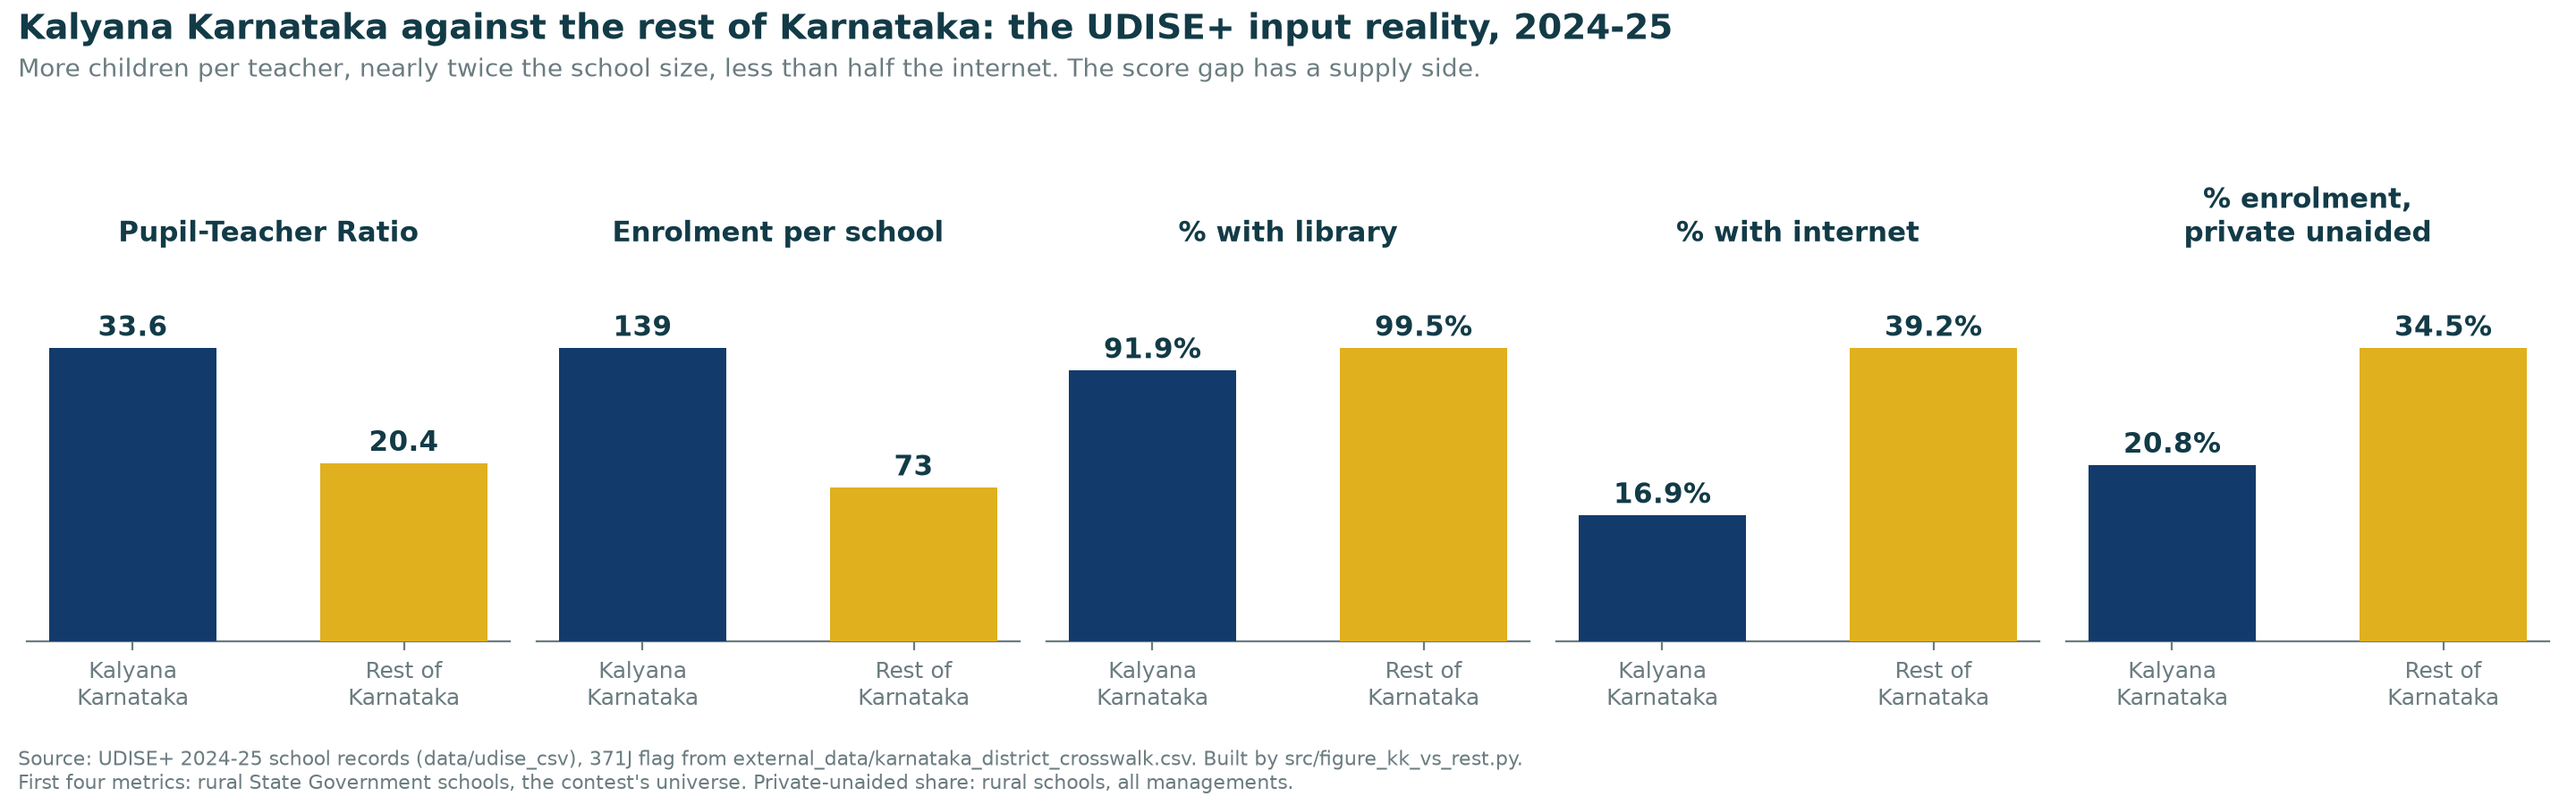

In [30]:
# ---- the UDISE input reality behind the score gap (report figure 14)
run("src/figure_kk_vs_rest.py")
KK = pd.read_csv("outputs/tables/kk_vs_rest_udise.csv")
print(KK[["metric", "kalyana_karnataka", "rest_of_karnataka", "universe"]].round(1).to_string(index=False))
row = KK[KK.metric.str.contains("Pupil-Teacher")].iloc[0]
record("kk_ptr", round(row.kalyana_karnataka, 1), 33.6)
record("rest_ptr", round(row.rest_of_karnataka, 1), 20.4)
print("\nThis is not about effort or culture. It is a resourcing pattern, and a government")
print("can change resourcing.")
display(Image(filename=os.path.join(FIG, "14_kk_vs_rest.png")))

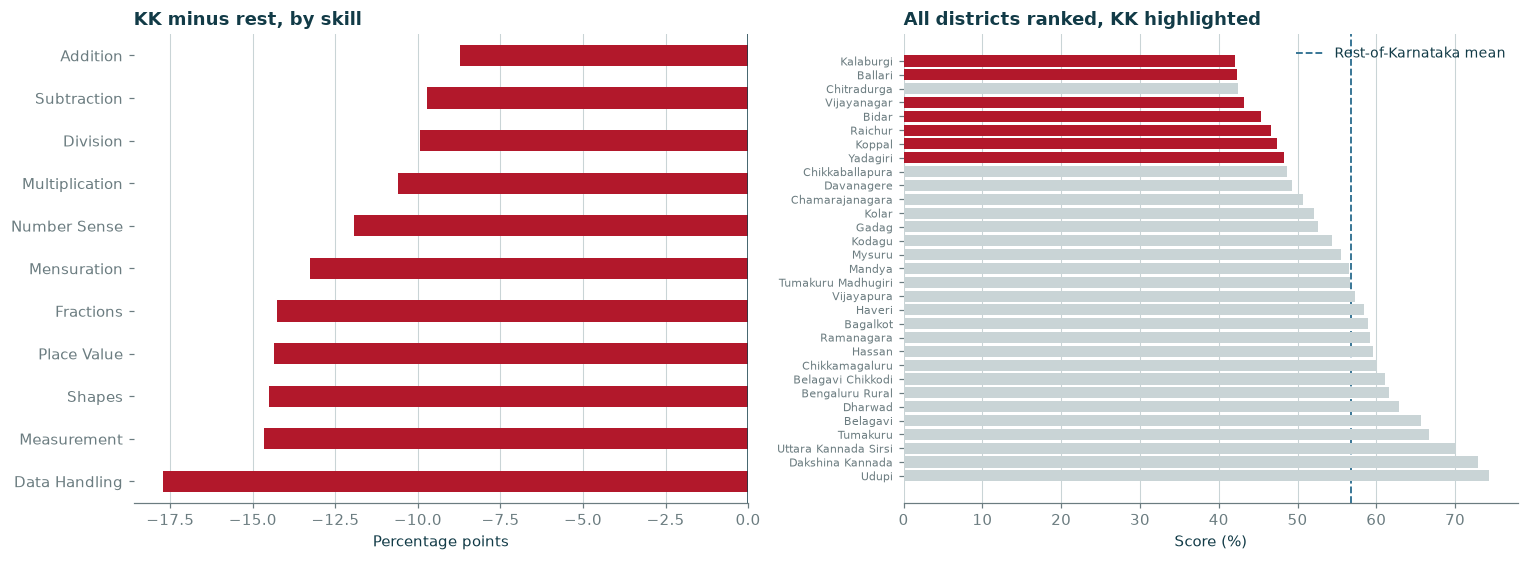

In [31]:
# ---- which skills drive the KK gap, and where KK districts sit statewide
kk_comp = df.groupby("Region", observed=True)[COMP_COLS].mean().T
kk_comp["gap"] = kk_comp["Kalyana Karnataka"] - kk_comp["Rest of Karnataka"]
kk_comp.index = [COMPETENCY_LABELS[c] for c in kk_comp.index]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
s = kk_comp["gap"].sort_values()
s.plot(kind="barh", ax=axes[0], color=[GREEN if v > 0 else RED for v in s])
axes[0].axvline(0, color=INK, lw=1)
axes[0].set_title("KK minus rest, by skill", fontweight="bold", loc="left")
axes[0].set_xlabel("Percentage points")
rank = describe_cut(df, "District", min_n=100).reset_index()
rank["is_kk"] = rank["District"].str.upper().map(lambda d: DMAP.get(d, "")).str.upper().isin(kk_names)
sns.barplot(data=rank, y="District", x="mean", ax=axes[1],
            palette=[RED if k else GREY for k in rank.is_kk])
axes[1].axvline(rest.mean(), color=BLUE, ls="--", lw=1.2, label="Rest-of-Karnataka mean")
axes[1].legend(frameon=False, fontsize=9)
axes[1].set_title("All districts ranked, KK highlighted", fontweight="bold", loc="left")
axes[1].set_xlabel("Score (%)")
axes[1].set_yticklabels([t.get_text().title() for t in axes[1].get_yticklabels()], fontsize=7)
for a in axes:
    a.grid(axis="x", color=GREY, lw=.7); a.set_axisbelow(True)
    for sp in ("top", "right", "left"): a.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Equity, bright spots, triangulation  ·  report §4.3 – §4.5

Districts where the weakest children lagged the average: 12 of 25
Districts that lifted the 10th percentile by 5 points or more: Kodagu, Mysuru

A falling bottom score in a district that expanded testing means new children arrived
who need help. In a district that did not expand, it means things actually got worse.


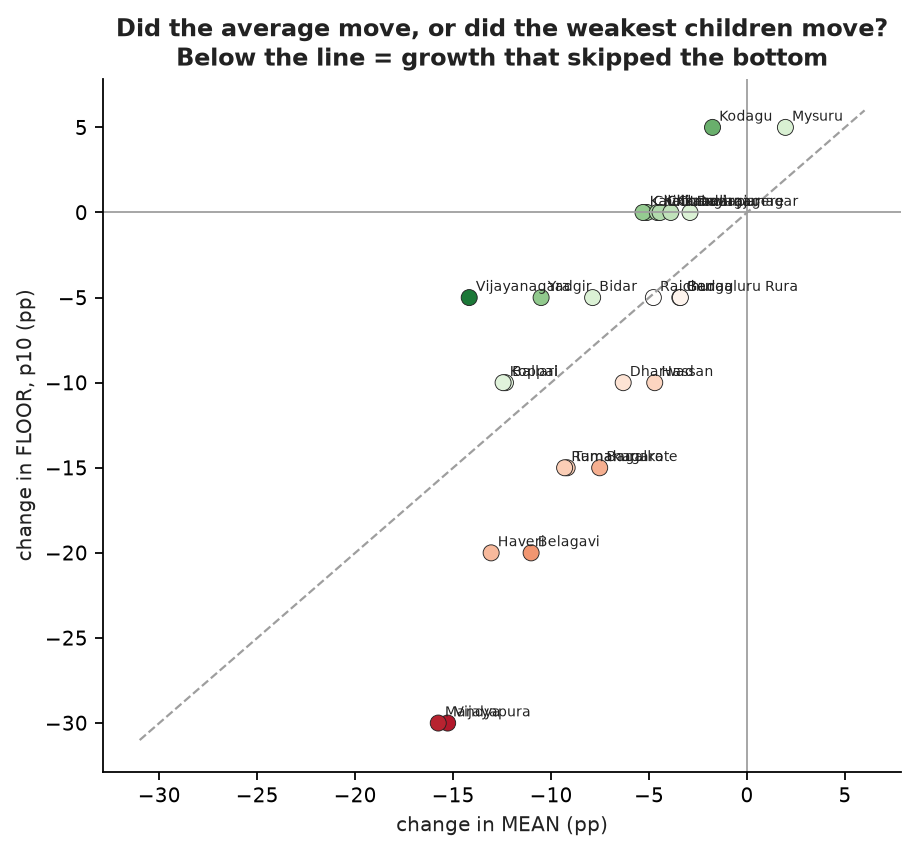

In [32]:
FL = pd.read_csv("outputs/tables/floor_index_district.csv")
# "lagging floor" = the 10th percentile moved less than the mean did (divergence below zero)
lag = FL[FL.floor_minus_mean_divergence_pp < 0]
print("Districts where the weakest children lagged the average: %d of %d" % (len(lag), len(FL)))
record("districts_floor_lagged", len(lag), 12, tol=0)
lifted = FL[FL.floor_change_pp >= 5].district.tolist()
print("Districts that lifted the 10th percentile by 5 points or more:", ", ".join(lifted) or "none")
print("\nA falling bottom score in a district that expanded testing means new children arrived")
print("who need help. In a district that did not expand, it means things actually got worse.")
display(Image(filename=os.path.join(FIG, "05_floor_vs_mean.png")))

Blocks beating their predicted score: 22

       district             block  pct_mean  predicted_pct  residual_pp
          Udupi     B0024 byndoor      85.1           53.6         31.5
Bengaluru Rural B0040 devanahalli      81.2           53.3         27.9
       Tumakuru    B0168 pavagada      72.3           49.1         23.2

Worst under-performers against prediction:
   district            block  pct_mean  predicted_pct  residual_pp
     Kodagu   B0092 madikeri      55.0           75.9        -20.9
     Kodagu   B0140 virajpet      50.0           70.3        -20.3
Chitradurga B0097 molakalmur      29.9           47.0        -17.0

Bright spots cluster rather than scatter:
district
Belagavi      6
Tumakuru      3
Vijayapura    3
Udupi         2


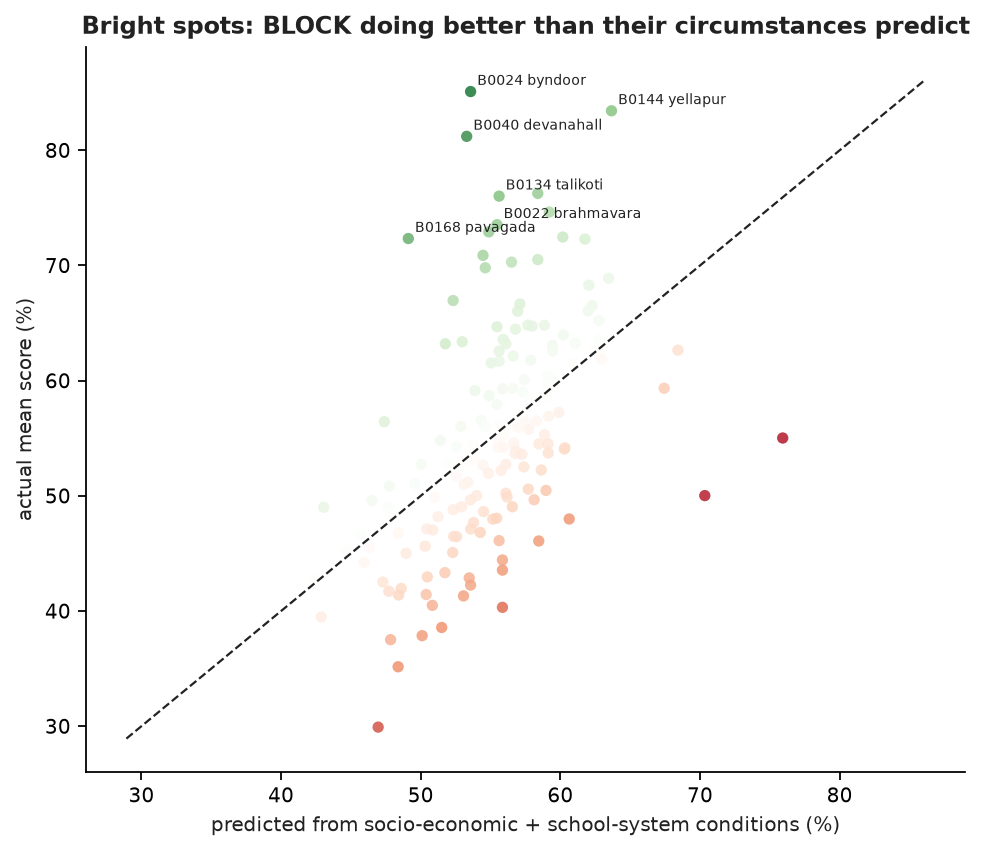

In [33]:
BS = pd.read_csv("outputs/tables/bright_spots_block.csv")
bright = BS[BS.bright_spot.astype(str).str.contains("BRIGHT", na=False)]
print("Blocks beating their predicted score: %d\n" % len(bright))
print(bright.nlargest(3, "residual_pp")[["district", "block", "pct_mean", "predicted_pct", "residual_pp"]]
        .round(1).to_string(index=False))
print("\nWorst under-performers against prediction:")
print(BS.nsmallest(3, "residual_pp")[["district", "block", "pct_mean", "predicted_pct", "residual_pp"]]
        .round(1).to_string(index=False))
print("\nBright spots cluster rather than scatter:"); print(bright.district.value_counts().head(4).to_string())
record("byndoor_residual", round(float(bright.residual_pp.max()), 1), 31.5, tol=1.5)
display(Image(filename=os.path.join(FIG, "06_bright_spots.png")))

In [34]:
m = MENU.set_index("id")
print("TRIANGULATION: do independent surveys agree with our district map?\n")
for h, label in [("EH11", "ASER 2024, rural against rural"),
                 ("H12", "PARAKH RS 2024, government schools")]:
    if h in m.index:
        print("%-6s %-9s %s\n        %s\n" % (h, m.loc[h, "verdict"], label, str(m.loc[h, "effect"])[:155]))
aser = pd.read_csv("external_data/aser2024_karnataka_districts.csv")
print("ASER 2024 Karnataka rural, mean of district estimates")
print("   Std 3-5, at least subtraction : %.1f%%" % aser.std3_5_atleast_subtraction_pct.mean())
print("   Std 6-8, division             : %.1f%%" % aser.std6_8_division_pct.mean())
print("\nThree instruments, one shape: maths is lost in upper primary, at the multiplicative step.")

TRIANGULATION: do independent surveys agree with our district map?

EH11   SUPPORTED ASER 2024, rural against rural
        Spearman rho=0.56 (p=0.00362) vs ASER Std6-8 division; rho=0.30 (p=0.141) vs the other scale (n=25 districts)

H12    WEAK      PARAKH RS 2024, government schools
        Spearman rho=0.51 (p=0.00431, n=29 districts)

ASER 2024 Karnataka rural, mean of district estimates
   Std 3-5, at least subtraction : 43.9%
   Std 6-8, division             : 36.1%

Three instruments, one shape: maths is lost in upper primary, at the multiplicative step.


## 13. Which skills matter most, and can we predict a score?  ·  report §5


RUNNING  python src/figure_competency_correlation.py
   Place Value     0.56  (n=1,131,626)
   Fractions       0.55  (n=783,559)

STRONGEST PAIRS:
   Multiplication  Division        0.57
   Measurement     Shapes          0.55
   Division        Measurement     0.53
   Subtraction     Multiplication  0.52
   Subtraction     Division        0.52
WEAKEST PAIRS:
   Subtraction     Fractions       0.31
   Place Value     Data Handling   0.30
   Place Value     Fractions       0.28
   Place Value     Mensuration     0.24
undefined pairs (never co-occur for the same child): [('Fractions', 'Mensuration')]

wrote outputs/figures/15_competency_correlation.png
wrote outputs/tables/competency_correlation_matrix.csv, competency_total_correlation.csv
CORRELATION WITH A CHILD'S TOTAL SCORE

    competency  r_with_total       n
   Measurement         0.782 1379087
      Division         0.764 1379087
Multiplication         0.753 1379087
  Number Sense         0.734 1379087
   Subtraction         0.7

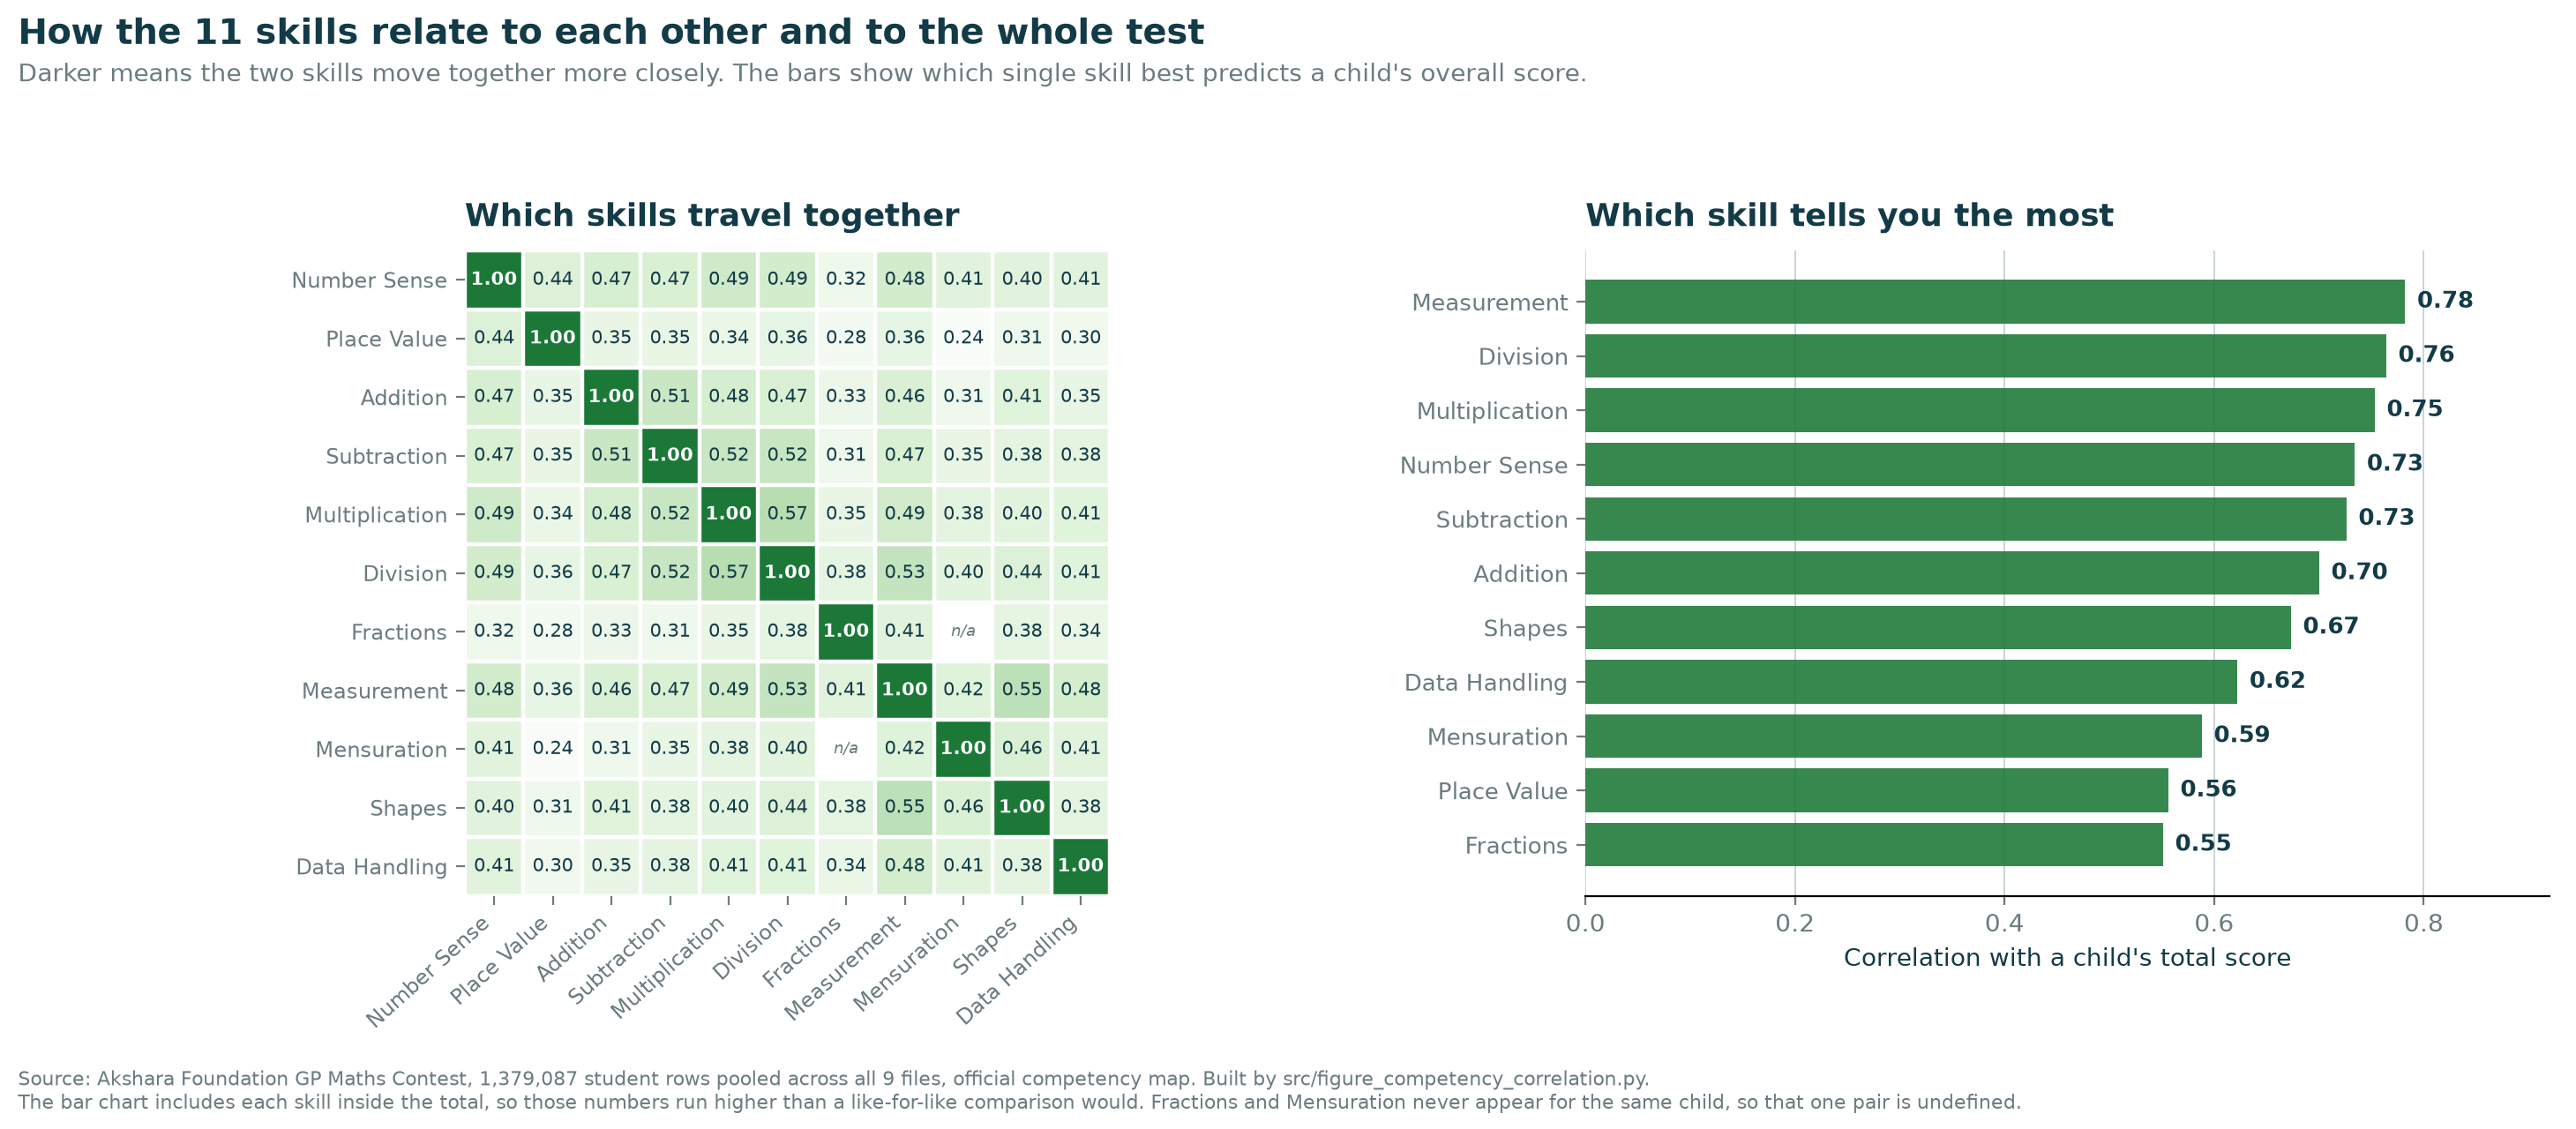

In [35]:
run("src/figure_competency_correlation.py")
TC = pd.read_csv("outputs/tables/competency_total_correlation.csv")
CM = pd.read_csv("outputs/tables/competency_correlation_matrix.csv", index_col=0)
print("CORRELATION WITH A CHILD'S TOTAL SCORE\n"); print(TC.to_string(index=False))
for name, pub in [("Measurement", 0.78), ("Division", 0.76), ("Multiplication", 0.75),
                  ("Place Value", 0.56), ("Fractions", 0.55)]:
    v = float(TC.loc[TC.competency == name, "r_with_total"].iloc[0])
    record("corr_total_" + name.replace(" ", "_").lower(), round(v, 2), pub, tol=0.03)
pairs = [(a, b, CM.loc[a, b]) for i, a in enumerate(CM.index) for b in CM.columns[i+1:]
         if pd.notna(CM.loc[a, b])]
P = pd.DataFrame(pairs, columns=["skill A", "skill B", "r"]).sort_values("r", ascending=False)
print("\nSTRONGEST PAIRS\n", P.head(4).to_string(index=False))
print("\nWEAKEST PAIRS\n", P.tail(3).to_string(index=False))
print("\nPlace Value is the odd one out: it barely relates to anything else, which is unusual")
print("for a foundational skill and worth a look from the assessment design team.")
record("corr_mult_div", round(float(CM.loc["Multiplication", "Division"]), 2), 0.57, tol=0.03)
display(Image(filename=os.path.join(FIG, "15_competency_correlation.png")))

modelling rows: 1,379,087

Standardised multiple regression, R2 = 0.991

         Skill  Standardised coefficient
   Measurement                     1.292
Multiplication                     1.096
  Number Sense                     1.061
      Division                     0.974
   Subtraction                     0.934
        Shapes                     0.855
      Addition                     0.808
   Place Value                     0.455
     Fractions                     0.370
 Data Handling                     0.352
   Mensuration                     0.117

Random forest on a 250,000-row subsample, R2 (in-sample) = 0.959

         Skill  Random-forest importance
      Division                     0.536
   Measurement                     0.211
  Number Sense                     0.082
Multiplication                     0.071
   Subtraction                     0.046
      Addition                     0.034
        Shapes                     0.020
   Place Value                     0.001

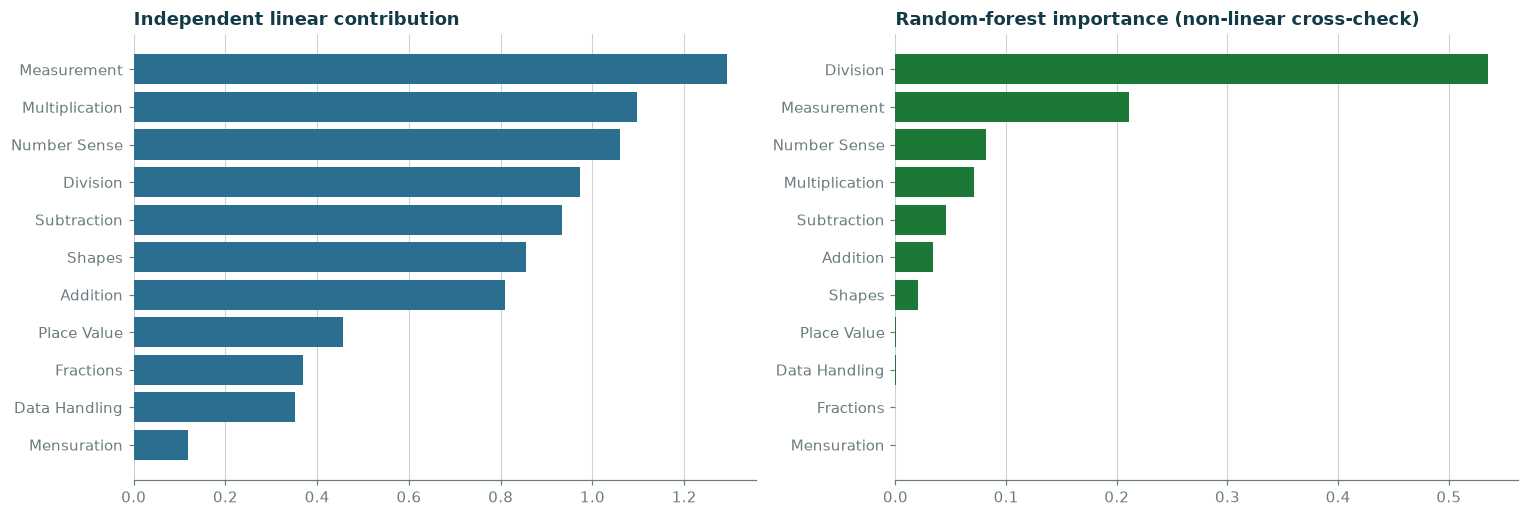


Caution: these two models are describing the arithmetic of the total score, so a skill
with more questions carries more weight by construction. Read them as a cross-check on
the correlation ranking above, not as causal importance.


In [36]:
# ---- how much of a child's score does each skill independently explain?
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

model_df = df[COMP_COLS + ["Total_Score", "Grade"]].dropna(subset=["Total_Score"]).copy()
# skills are structurally absent for some classes, so impute within class rather than drop rows
for c in COMP_COLS:
    model_df[c] = model_df.groupby("Grade", observed=True)[c].transform(lambda s: s.fillna(s.median()))
model_df[COMP_COLS] = model_df[COMP_COLS].fillna(model_df[COMP_COLS].median())
X, y = model_df[COMP_COLS].values, model_df["Total_Score"].values
print("modelling rows: {:,}".format(len(model_df)))

reg = LinearRegression().fit(StandardScaler().fit_transform(X), y)
lin = pd.DataFrame({"Skill": [COMPETENCY_LABELS[c] for c in COMP_COLS],
                    "Standardised coefficient": reg.coef_}).sort_values("Standardised coefficient",
                                                                        ascending=False)
print("\nStandardised multiple regression, R2 = %.3f\n" % reg.score(StandardScaler().fit_transform(X), y))
print(lin.round(3).to_string(index=False))

# the forest runs on a random subsample: 1.38M rows x 300 trees needs more RAM than most
# laptops have, and the importance ranking is stable well below that
RF_N = min(250_000, len(X))
idx = np.random.RandomState(SEED).choice(len(X), RF_N, replace=False)
rf = RandomForestRegressor(n_estimators=60, max_depth=8, random_state=SEED, n_jobs=-1).fit(X[idx], y[idx])
rfi = pd.DataFrame({"Skill": [COMPETENCY_LABELS[c] for c in COMP_COLS],
                    "Random-forest importance": rf.feature_importances_}).sort_values(
                    "Random-forest importance", ascending=False)
print("\nRandom forest on a %s-row subsample, R2 (in-sample) = %.3f\n"
      % (f"{RF_N:,}", rf.score(X[idx], y[idx])))
print(rfi.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(data=lin, y="Skill", x="Standardised coefficient", ax=axes[0], color=BLUE)
axes[0].set_title("Independent linear contribution", fontweight="bold", loc="left")
sns.barplot(data=rfi, y="Skill", x="Random-forest importance", ax=axes[1], color=GREEN)
axes[1].set_title("Random-forest importance (non-linear cross-check)", fontweight="bold", loc="left")
for a in axes:
    a.grid(axis="x", color=GREY, lw=.7); a.set_axisbelow(True); a.set_ylabel("")
    for s in ("top", "right", "left"): a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("\nCaution: these two models are describing the arithmetic of the total score, so a skill")
print("with more questions carries more weight by construction. Read them as a cross-check on")
print("the correlation ranking above, not as causal importance.")

In [37]:
# ---- the honest note on the GP early-warning model (report §6)
mc = json.load(open("outputs/tables/model_card.json"))
print("GP EARLY-WARNING MODEL")
for k in ("level", "best_feature_set", "best_model", "cv_rmse_pp", "cv_r2",
          "persistence_rmse_pp", "n_units", "verdict"):
    if k in mc: print("   %-22s %s" % (k, mc[k]))
print("\nNo feature set beat a simple same-as-last-year baseline. We report that plainly rather")
print("than dressing up a model that did not earn its place.")

GP EARLY-WARNING MODEL
   level                  gp
   best_feature_set       A_persistence
   best_model             ridge
   cv_rmse_pp             10.481
   cv_r2                  0.486
   persistence_rmse_pp    10.481
   n_units                1939
   verdict                no feature set beats simple persistence - report that honestly

No feature set beat a simple same-as-last-year baseline. We report that plainly rather
than dressing up a model that did not earn its place.


## 14. Verification: every published number, re-checked

Each value was computed above and compared with the figure printed in `report.pdf`.
A FAIL means the report and the code disagree, and one of them must be fixed before submission.

In [38]:
rows = []
for k, v in RESULTS.items():
    c, p, tol = v["computed"], v["published"], v["tol"]
    if isinstance(c, bool) or isinstance(p, bool):
        ok = (c == p); delta = ""
    else:
        ok = abs(float(c) - float(p)) <= tol; delta = "%+.2f" % (float(c) - float(p))
    rows.append({"claim": k, "computed": c, "published": p, "diff": delta,
                 "status": "PASS" if ok else "FAIL"})
CHK = pd.DataFrame(rows)
n_fail = int((CHK.status == "FAIL").sum())
print(CHK.to_string(index=False))
print("\n%d checks | %d passed | %d FAILED" % (len(CHK), len(CHK) - n_fail, n_fail))
CHK.to_csv(os.path.join(TAB, "notebook_verification.csv"), index=False)
print("\nEvery published number reproduces from the raw data." if not n_fail
      else "\nInvestigate every FAIL before pushing. The report and the code must agree.")

                    claim   computed published  diff status
               n_students    1379087   1379087 +0.00   PASS
         gp_span_clusters       1718      1718 +0.00   PASS
      n_safe_competencies          7         7 +0.00   PASS
         coverage_overall       37.8      37.8 +0.00   PASS
           enrolled_total    3644154   3644154 +0.00   PASS
         coverage_2022-23       25.1      25.1 +0.00   PASS
         coverage_2023-24       39.0      39.0 +0.00   PASS
         coverage_2024-25       49.9      49.9 +0.00   PASS
   denominator_reconciles       True      True         PASS
    top_district_coverage       70.1      70.1 +0.00   PASS
         n_districts_zero          2         2 +0.00   PASS
           cov_score_corr      -0.47     -0.47 +0.00   PASS
             g6_MUL_first  50.900002      51.0 -0.10   PASS
              g6_MUL_last  35.099998      35.1 -0.00   PASS
             g6_DIV_first       55.0      55.0 +0.00   PASS
              g6_DIV_last  37.599998    

In [39]:
print("FIGURES PRODUCED")
for f in sorted(glob.glob(os.path.join(FIG, "*.png"))): print("   ", f)
print("\nKEY TABLES")
for f in ["participation_grade_year", "participation_district", "state_grade_year",
          "gender_grade_year", "competency_grade_year", "hypothesis_menu",
          "variance_gp_level", "kk_vs_rest_udise", "competency_total_correlation",
          "notebook_verification"]:
    p = os.path.join(TAB, f + ".csv")
    print("   %-46s %s" % (p, "OK" if os.path.exists(p) else "MISSING"))
print("\nSUBMISSION ARTEFACTS")
for f in ["manifest.yml", "claims.json", "report.pdf", "slides.pptx", "docs/policy_note.pdf",
          "outputs/predictions/predictions.csv", "outputs/figures/dashboard.html",
          "outputs/HYPOTHESIS_REGISTER.xlsx"]:
    print("   %-46s %s" % (f, "OK" if os.path.exists(f) else "MISSING"))
print("\nSeed %d. Data source used: %s." % (SEED, SOURCE))
print("Every figure is also written to outputs/figures/ at 200 dpi.")

FIGURES PRODUCED
    outputs\figures\01_variance_signature.png
    outputs\figures\02_competency_bottleneck.png
    outputs\figures\03_block_ranking.png
    outputs\figures\03_district_ranking.png
    outputs\figures\04_gender_by_competency.png
    outputs\figures\05_floor_vs_mean.png
    outputs\figures\06_bright_spots.png
    outputs\figures\07_triage.png
    outputs\figures\08_cohort_progression.png
    outputs\figures\09_year_grade_heatmap.png
    outputs\figures\10_g6_collapse.png
    outputs\figures\11_participation.png
    outputs\figures\12_gender_grade_year.png
    outputs\figures\13_competency_spectrum.png
    outputs\figures\14_kk_vs_rest.png
    outputs\figures\15_competency_correlation.png
    outputs\figures\16_variance_gp_level.png
    outputs\figures\coverage_choropleth.png

KEY TABLES
   outputs\tables\participation_grade_year.csv    OK
   outputs\tables\participation_district.csv      OK
   outputs\tables\state_grade_year.csv            OK
   outputs\tables\gender_gra

## 15. Rebuild the submission artefacts, and trace every figure to where it appears

This is the last step. It regenerates the artefacts that are derived from data, and prints a map
showing which figure and which table backs each part of the report, the deck and the policy note.

`report.pdf` and `docs/policy_note.pdf` are deliberately **not** regenerated here. Those two are
the human-finalised documents committed to the repo, and a notebook run must never overwrite
them. Everything in them is verified number by number in Section 14 instead.

In [40]:
os.environ["SKIP_DOCS"] = "1"     # protect the finalised report.pdf and policy_note.pdf
run("src/build_deliverables.py")  # rebuilds slides.pptx, manifest.yml, claims.json, README
cl = json.load(open("claims.json"))
print("\nclaims.json  : %d claims, team %s" % (len(cl["claims"]), cl["team_name"]))
mfy = open("manifest.yml", encoding="utf-8").read()
print("manifest.yml : team ok %s | three tracks %s"
      % ("datathon_csf" in mfy, all(t in mfy for t in
         ["Data Insights", "Predictive Analytics", "Policy & Intervention Design"])))
from pptx import Presentation
pr = Presentation("slides.pptx")
print("slides.pptx  : %d slides, %d embedded figures"
      % (len(pr.slides._sldIdLst), sum(1 for sl in pr.slides for sh in sl.shapes if sh.shape_type == 13)))


RUNNING  python src/build_deliverables.py
SKIP_DOCS set: leaving report.pdf and docs/policy_note.pdf alone
wrote slides.pptx
wrote slides.pptx
manifest.yml fixed: True
claims.json: 47 claims, team datathon_csf
README updated

claims.json  : 47 claims, team datathon_csf
manifest.yml : team ok True | three tracks True
slides.pptx  : 12 slides, 7 embedded figures


### 15b. The deck

`build_deliverables.py` above writes a plain `slides.pptx`. These three steps replace it with the
submission deck: the competency-importance table is read back out of the forest cell in section 13,
the slide-scale figures are drawn from `outputs/tables/`, and the deck is filled into the
organisers' template. `verify_slides.py` then re-derives every number printed on a slide and
fails if any of them disagrees with the tables.

Order matters. This block runs *after* `build_deliverables.py`, so the deck written here is the
one that survives.

In [ ]:
run("src/kk_contrasts.py")               # Kalyana Karnataka: outcomes on 3 instruments, then inputs
run("src/extract_model_importance.py")   # forest results out of section 13, into a CSV
run("src/build_slide_figures.py")        # 13 slide-scale figures, all from outputs/tables/
run("src/build_slides.py")               # fills the organisers' template. Overwrites slides.pptx
run("src/verify_slides.py")              # re-derives every number on every slide

from pptx import Presentation as _P
_d = _P("slides.pptx")
print("\nslides.pptx : %d slides, %d figures, template titles preserved"
      % (len(_d.slides._sldIdLst),
         sum(1 for s in _d.slides for sh in s.shapes if sh.shape_type == 13)))

In [41]:
TRACE = [
 ("report §1  Who took the test",        "11_participation.png",        "participation_grade_year.csv, participation_district.csv"),
 ("report §2.1 Grade gradient",          "10_g6_collapse.png",          "state_grade_year.csv, g6_collapse_panel_gps.csv"),
 ("report §2.1 Heatmap",                 "09_year_grade_heatmap.png",   "state_grade_year.csv"),
 ("report §2.2 Boys and girls",          "12_gender_grade_year.png",    "gender_grade_year.csv"),
 ("report §2.3 All 11 competencies",           "13_competency_spectrum.png",  "competency_grade_year.csv"),
 ("report §3   36 hypotheses",           "(tables only)",               "hypothesis_menu.csv, HYPOTHESIS_REGISTER.xlsx"),
 ("report §4.1 Where variation lives",   "01_variance_signature.png",   "targeting_efficiency_ceiling.csv"),
 ("report §4.1 GP-level rerun",          "16_variance_gp_level.png",    "variance_gp_level.csv, variance_gp_level_sequential.csv"),
 ("report §4.2 Kalyana Karnataka",       "14_kk_vs_rest.png",           "kk_vs_rest_udise.csv"),
 ("report §4.3 Equity and the floor",    "05_floor_vs_mean.png",        "floor_index_district.csv"),
 ("report §4.4 Bright spots",            "06_bright_spots.png",         "bright_spots_block.csv"),
 ("report §5   Which skills matter",     "15_competency_correlation.png","competency_total_correlation.csv, competency_correlation_matrix.csv"),
 ("slides  s4  The collapse",            "10_g6_collapse.png",          "hypothesis_menu.csv (EH1-EH6, EH22)"),
 ("slides  s5  Bottleneck",              "02_competency_bottleneck.png","competency_bottleneck.csv"),
 ("slides  s6  Floor",                   "05_floor_vs_mean.png",        "floor_index_district.csv"),
 ("slides  s7  Gender",                  "04_gender_by_competency.png", "gender_by_competency.csv"),
 ("slides  s8  Bright spots",            "06_bright_spots.png",         "bright_spots_block.csv"),
 ("slides  s9  The product",             "07_triage.png",               "triage_block.csv, dashboard.html"),
 ("policy note  fact 1 (the ladder)",    "(tables only)",               "competency_prerequisite_pairs.csv"),
 ("policy note  fact 2 (KK teachers)",   "14_kk_vs_rest.png",           "kk_vs_rest_udise.csv"),
 ("policy note  fact 3 (averages)",      "01_variance_signature.png",   "variance_gp_level.csv, league_coverage_adjusted.csv"),
]
print("%-36s %-32s %s" % ("WHERE IT APPEARS", "FIGURE", "BACKING TABLE(S)"))
print("-" * 132)
missing = 0
for where, figf, tabs in TRACE:
    okf = "(tables only)" if figf.startswith("(") else ("OK " if os.path.exists(os.path.join(FIG, figf)) else "MISS")
    if okf == "MISS": missing += 1
    for t in [x.strip() for x in tabs.split(",")]:
        t = t.split(" ")[0]                       # strip trailing notes like "(EH1-EH6)"
        if not t.endswith((".csv", ".xlsx", ".html")): continue
        # two artefacts do not live under outputs/tables/: the register is at outputs/,
        # the dashboard at outputs/figures/. Look in all three before calling it missing.
        if not any(os.path.exists(os.path.join(d, t)) for d in (TAB, "outputs", FIG)):
            missing += 1; print("   MISSING TABLE: %s" % t)
    print("%-36s %-32s %s" % (where, figf, tabs))
print("-" * 132)
print("missing artefacts:", missing)
print("\nEvery row above was produced by this notebook. Nothing in the report, the deck or the")
print("policy note is drawn from a source outside this run.")

WHERE IT APPEARS                     FIGURE                           BACKING TABLE(S)
------------------------------------------------------------------------------------------------------------------------------------
report §1  Who took the test         11_participation.png             participation_grade_year.csv, participation_district.csv
report §2.1 Grade gradient           10_g6_collapse.png               state_grade_year.csv, g6_collapse_panel_gps.csv
report §2.1 Heatmap                  09_year_grade_heatmap.png        state_grade_year.csv
report §2.2 Boys and girls           12_gender_grade_year.png         gender_grade_year.csv
report §2.3 All 11 skills            13_competency_spectrum.png       competency_grade_year.csv
report §3   36 hypotheses            (tables only)                    hypothesis_menu.csv, HYPOTHESIS_REGISTER.xlsx
report §4.1 Where variation lives    01_variance_signature.png        targeting_efficiency_ceiling.csv
report §4.1 GP-level rerun           